# interpolation functions

In [1]:
%cd ../
import torchtt as tntt
import torch as tn
from src.qtt_interpolation.utils import *
from src.qtt_interpolation.int_tools import *
from src.qtt_interpolation.comb import *



/home/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/nfs/users/siddhartha.morales/TTinterpolation/QTT-polynomial-interpolation


# 3D wing

This notebook contains the embedding of a 3D version of basic airplane wing without a winglet. 

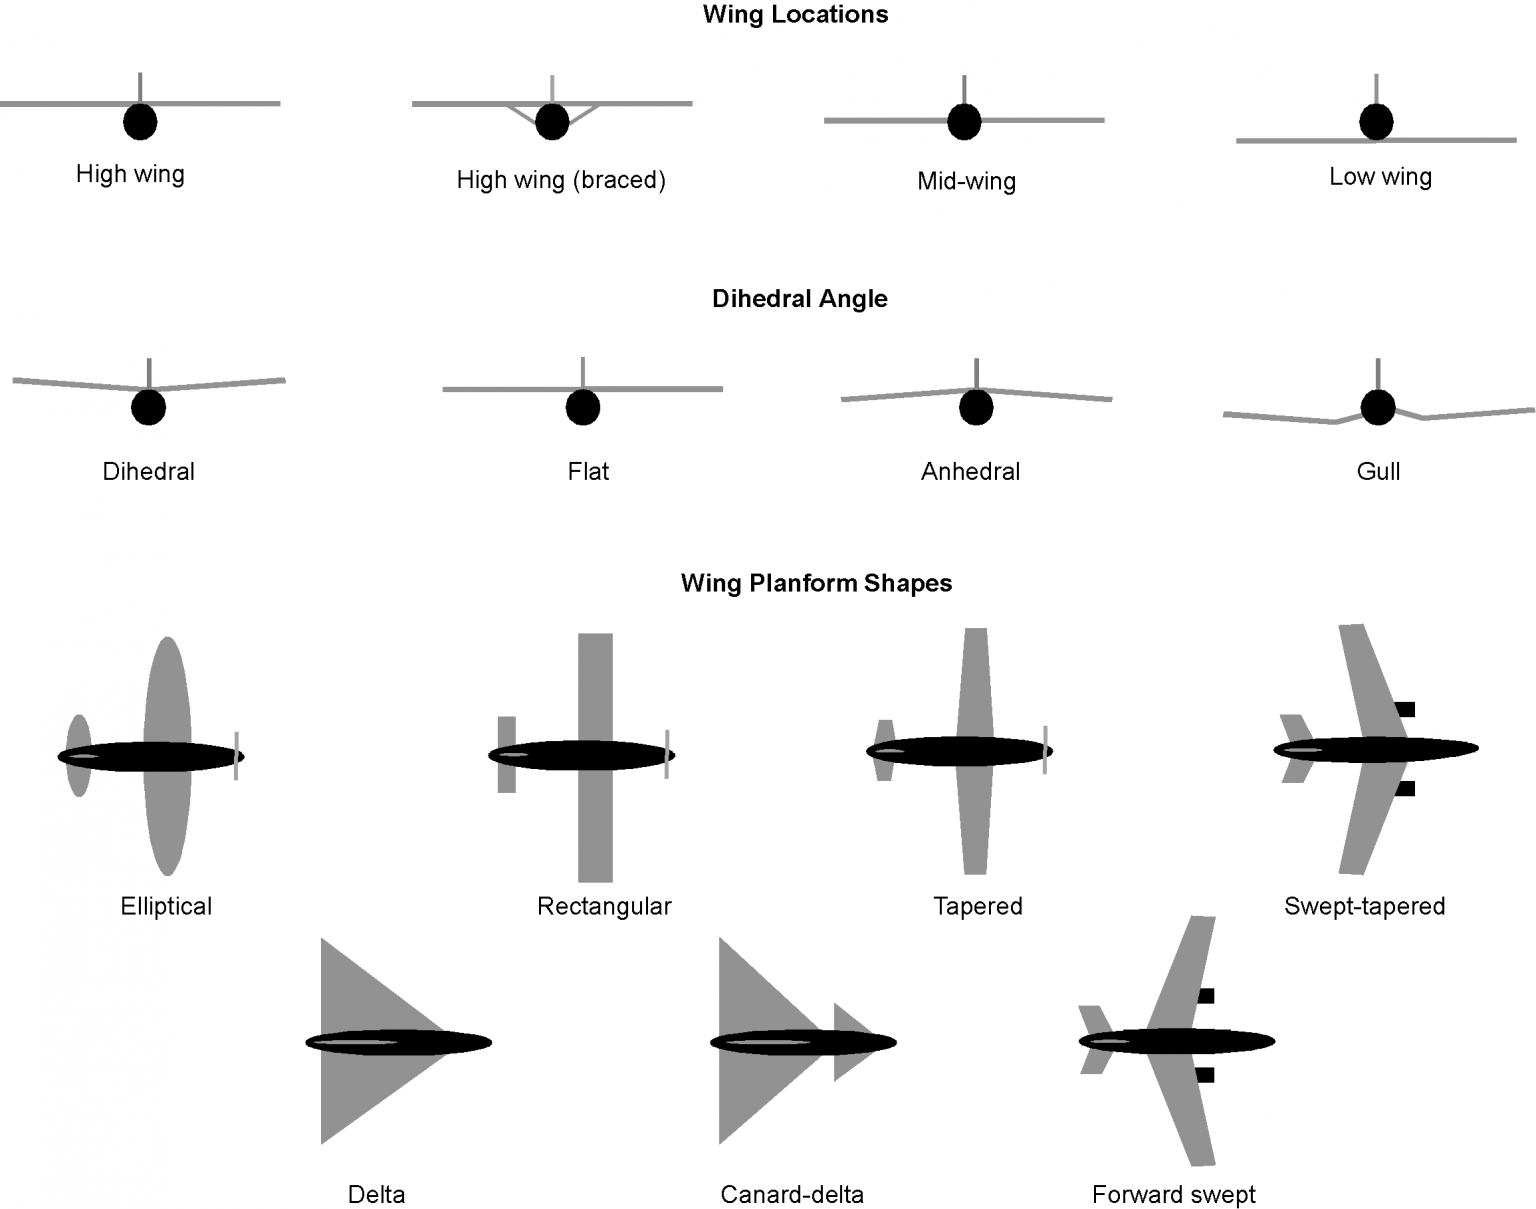

In [21]:
%matplotlib ipympl

## Model 1

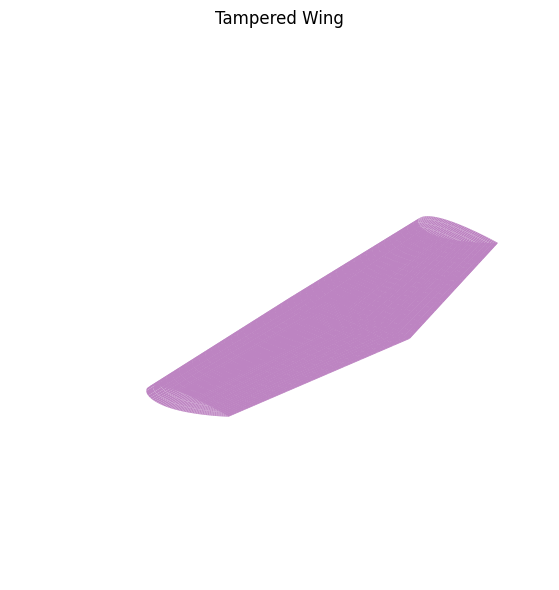

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── Parameters ───────────────────────────────────────────────────────────────
b = 2.0
c_r = 1.0
c_t = 0.5
Lambda_LE = np.deg2rad(15)
phi = 0.2*np.deg2rad(3)
t = 0.12

def chord(eta): 
    return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2

def x_le(eta): 
    return 0.5 * b * eta * np.tan(Lambda_LE)

def z_planform(eta): 
    return 0.5 * b * eta * np.tan(phi)

def y_t(xi):
    # NACA-like thickness distribution scaled by t
    return t * (0.2969 * np.sqrt(xi)
                - 0.1260 * xi
                - 0.3516 * xi**2
                + 0.2843 * xi**3
                - 0.1015 * xi**4)

# ── Finer grid for smoother surface ──────────────────────────────────────────
eta_vals = np.linspace(-1, 1, 220)
xi_vals  = np.linspace(0, 1, 220)
XI, ETA  = np.meshgrid(xi_vals, eta_vals)

# ── Geometry ─────────────────────────────────────────────────────────────────
C       = chord(ETA)
X_sec   = XI * C
Z_thick = C * y_t(XI)

X = x_le(ETA) + X_sec
Y = 0.5 * b * ETA
Z_upper = z_planform(ETA) + Z_thick
Z_lower = z_planform(ETA) - Z_thick

# Normalize to a box for consistent framing
max_val = np.max(np.abs([X, Y, Z_upper, Z_lower]))
X /= max_val; Y /= max_val; Z_upper /= max_val; Z_lower /= max_val

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Make panes pure white and hide their edges
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.set_facecolor((1, 1, 1, 1))
    pane.set_edgecolor((1, 1, 1, 0))

# Single color (monochrome), flat shading
mono = "#BD84C2"  # pale purple
ax.plot_surface(X, Y, Z_upper, color=mono, linewidth=0, antialiased=True, shade=False)
ax.plot_surface(X, Y, Z_lower, color=mono, linewidth=0, antialiased=True, shade=False)

# Limits & aspect
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-0.05, 0.05])
ax.set_box_aspect((2, 2, 1))  # keep thin vertical proportion

# Remove axis labels and ticks; hide axis lines
ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.line.set_color((1, 1, 1, 0))  # hide 3D box edges
ax.grid(False)

# Title
ax.set_title("Tampered Wing", pad=12)

plt.tight_layout()

# Optional: save with a solid white background
# plt.savefig("tampered_wing.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


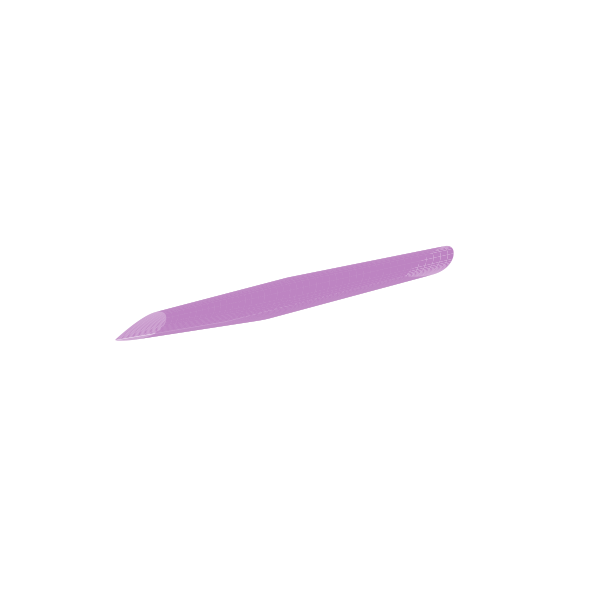

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import animation

# ── Parameters ───────────────────────────────────────────────────────────────
b = 2.0
c_r = 1.0
c_t = 0.5
Lambda_LE = np.deg2rad(15)
phi = 0.7*np.deg2rad(3)
t = 0.12

def chord(eta):
    return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2

def x_le(eta):
    return 0.5 * b * eta * np.tan(Lambda_LE)

def z_planform(eta):
    return 0.5 * b * eta * np.tan(phi)

def y_t(xi):
    # NACA-like thickness distribution scaled by t
    return t * (0.2969*np.sqrt(xi) - 0.1260*xi - 0.3516*xi**2
                + 0.2843*xi**3 - 0.1015*xi**4)

# ── Grid (smooth) ────────────────────────────────────────────────────────────
eta_vals = np.linspace(-1, 1, 220)
xi_vals  = np.linspace(0, 1, 220)
XI, ETA  = np.meshgrid(xi_vals, eta_vals)

# ── Geometry ─────────────────────────────────────────────────────────────────
C       = chord(ETA)
X_sec   = XI * C
Z_thick = C * y_t(XI)

X = x_le(ETA) + X_sec
Y = 0.5 * b * ETA
Z_upper = z_planform(ETA) + Z_thick
Z_lower = z_planform(ETA) - Z_thick

# Normalize to a box for consistent framing
max_val = np.max(np.abs([X, Y, Z_upper, Z_lower]))
X /= max_val; Y /= max_val; Z_upper /= max_val; Z_lower /= max_val

# ── Figure (white bg, no axes) ───────────────────────────────────────────────
fig = plt.figure(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# White panes and invisible edges
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.set_facecolor((1, 1, 1, 1))
    pane.set_edgecolor((1, 1, 1, 0))

# Plot surfaces once (pale purple)
mono = "#BD84C2"
ax.plot_surface(X, Y, Z_upper, color=mono, linewidth=0, antialiased=True, shade=False)
ax.plot_surface(X, Y, Z_lower, color=mono, linewidth=0, antialiased=True, shade=False)

# Limits, aspect, and remove everything axis-y
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-0.05, 0.05])
ax.set_box_aspect((2, 2, 1))
ax.set_axis_off()
plt.tight_layout()

# ── Animation (rotate azimuth) ───────────────────────────────────────────────
FRAMES = 180       # full rotation frames
FPS    = 30        # playback speed
ELEV   = 15        # camera elevation
AZ0    = 30        # starting azimuth

def update(frame):
    az = AZ0 + 360.0 * frame / FRAMES
    ax.view_init(elev=ELEV, azim=az)
    return ax,

ani = animation.FuncAnimation(fig, update, frames=FRAMES, interval=1000/FPS, blit=False)

# Save as GIF (requires Pillow: pip install pillow)
ani.save("tampered_wing_spin.gif",
         writer=animation.PillowWriter(fps=FPS),
         dpi=120,
         savefig_kwargs={'facecolor': 'white', 'bbox_inches': 'tight'})

# If you also want to preview interactively:
# plt.show()


0.012003444536256099 0.75
Approximate max thickness at root chord: 0.01800516680438415


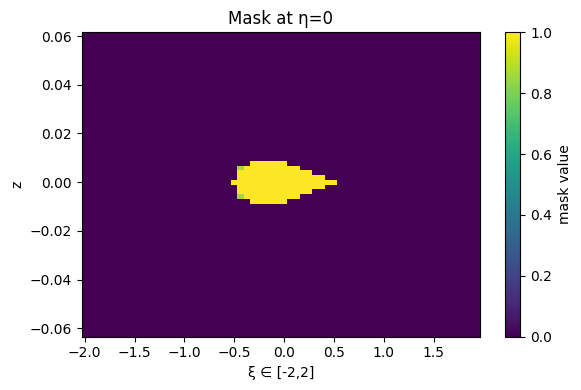

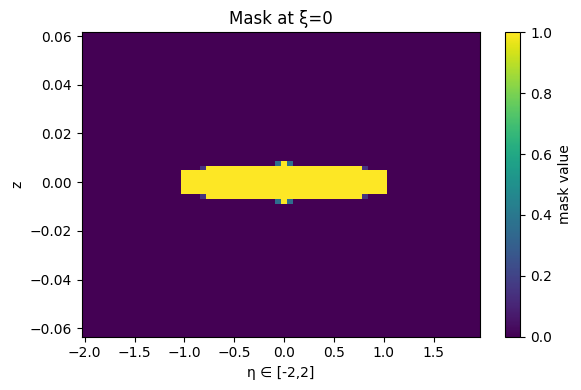

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# --- Wing parameterization ---
b, c_r, c_t = 2.0, 1.0, 0.5
Lambda_LE = np.deg2rad(15)
phi       = 0.0
t         = 0.12

def chord(eta):
    return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2

def z_planform(eta):
    return 0.5 * b * eta * np.tan(phi)

def y_t(xi):
    return t*(0.2969 * np.sqrt(xi)
             - 0.1260 * xi
             - 0.3516 * xi**2
             + 0.2843 * xi**3
             - 0.1015 * xi**4)

# --- Create 3D grid over eta, xi, z  ---
p        = 6
zlim     = 1/16
eta_vals = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**p, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
ETA, XI, ZG = np.meshgrid(eta_vals, xi_ext, z_vals, indexing='ij')

# --- Valid chordwise band for surface definition (xi in [-0.5,0.5]) ---
mask_band = (XI[:,:,0] >= -0.5) & (XI[:,:,0] <= 0.5)

# Compute 2D upper/lower z in that band
Zup2d  = np.zeros_like(ETA[:,:,0])
Zlow2d = np.zeros_like(ETA[:,:,0])

xi_param = XI[:,:,0][mask_band] + 0.5
eta_m    = ETA[:,:,0][mask_band]
C_m      = chord(eta_m)
Zt       = C_m * y_t(xi_param)

Zup2d[mask_band]  = z_planform(eta_m) + Zt
Zlow2d[mask_band] = z_planform(eta_m) - Zt

# Broadcast to 3D
Zup3d  = Zup2d[:,:,None] * np.ones_like(ZG)
Zlow3d = Zlow2d[:,:,None] * np.ones_like(ZG)

# Precompute thickness scale
xi_test      = np.linspace(0,1,1000)
max_y_t      = np.max(y_t(xi_test))
c_root       = chord(0.0)
real_thick   = 2 * c_root * max_y_t
print(max_y_t,c_root)
print("Approximate max thickness at root chord:", real_thick)

# --- Build mask, default = 1 everywhere ---
mask = np.ones_like(ZG)

# Define the “core” region in eta and xi:
mask_eta = (ETA[:,:,0] >= -1.0) & (ETA[:,:,0] <= 1.0)
mask_xi  = (XI[:,:,0]  >= -1.0) & (XI[:,:,0]  <= 1.0)
mask_core = mask_eta & mask_xi

# 1) Inside wing (flat) → mask = 0
inside = mask_core[:,:,None] & mask_band[:,:,None] & (ZG >= Zlow3d) & (ZG <= Zup3d)
mask[inside] = 0.0

# 2) Above upper surface → exponential falloff
above = mask_core[:,:,None] & mask_band[:,:,None] & (ZG > Zup3d)
zd_above = ZG - Zup3d
mask[above] = 1 - np.exp(-(500/real_thick) * zd_above[above])

# 3) Below lower surface → exponential falloff
below = mask_core[:,:,None] & mask_band[:,:,None] & (ZG < Zlow3d)
zd_below = Zlow3d - ZG
mask[below] = 1 - np.exp(-(500/real_thick) * zd_below[below])


mask = 1 - mask
# --- Optional: visualize central slices ---
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mask[i0,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask[:,j0,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()


In [4]:
(2**6)**3

262144

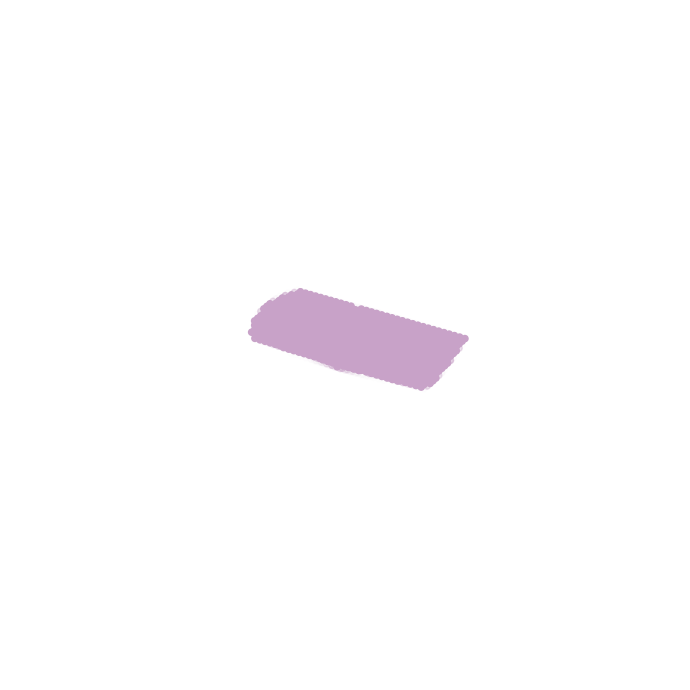

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Build RGBA (pale purple) with alpha = 1 - mask
N = mask.size
rgb = mcolors.to_rgb("#C8A2C8")
alpha = np.clip(mask.ravel(), 0.0, 1.0)  # inside=opaque (1), outside→transparent (0)
rgba = np.column_stack([np.tile(rgb, (N, 1)), alpha])

# Randomly select up to 10,000 points
idx = np.random.choice(N, size=min(260000, N), replace=False)
X_s = ETA.ravel()[idx]
Y_s = XI.ravel()[idx]
Z_s = ZG.ravel()[idx]
rgba_s = rgba[idx]

# Symmetric z-limits
zlim = float(np.max(np.abs(ZG)))

# Figure/axes with white background and no axes
fig = plt.figure(figsize=(7, 7))
fig.patch.set_facecolor('white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Make panes white & hide box edges
for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
    pane.set_facecolor((1, 1, 1, 1))
    pane.set_edgecolor((1, 1, 1, 0))

# Scatter (disable depth shading to keep color flat)
ax.scatter(X_s, Y_s, Z_s, c=rgba_s, marker='o', s=20, depthshade=False)

# Limits/aspect and hide all axes
ax.set_zlim(-zlim, zlim)
#ax.set_box_aspect((np.ptp(X_s), np.ptp(Y_s), np.ptp(Z_s)))
ax.set_axis_off()

plt.tight_layout()
# Optional: save with white background
# plt.savefig("mask_scatter_10k.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()


In [5]:
tnmask = tn.tensor(mask,dtype=tn.float64)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R),erank(ttmask.R,ttmask.N))


271 147.52056233798237


In [6]:
qttmask = tntt.TT(zM3(tnmask,p),[2,2,2]*p).round(1e-3)
#tmf = z_order_to_normal_nopara(qttmask.full().cpu().numpy().ravel(), np.zeros((2**p, 2**p, 2**p)), 2**p, 2**p, 2**p).T
print( np.max(qttmask.R) , erank(qttmask.R,qttmask.N) )

327 101.6088270919001


In [7]:
N = 2**p
tmfull = ttmask.full().reshape(N,N,N)
print(tmfull.shape)
tmf = tn.zeros(N,N,N)
for i in range(2**p):
    tmf[i,:,:] = z_order_to_normal_torch(tmfull[i,:,:].flatten(),N,N).T
tmf = tmf[x_order,:,:]
tmf = tmf.cpu().numpy()


torch.Size([256, 256, 256])


In [ ]:


# --- Invert alpha: alpha = 1 - mask ---
rgba = np.zeros((tmf.size, 4))
rgba[:, 3] = (1 - tmf).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0
# Min-max normalization of alpha channel (rgba[:, 3]) to [0, 1]
rgba = np.clip(rgba, 0, 1)

# Plot 3D scatter with transparency
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    ETA.ravel(), XI.ravel(), ZG.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [9]:
qtt_int = qtt_skcubic3d_p(qttmask, 9, eps = 1e-3, order=2)
qtt_int

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 8, 8, 16, 16, 27, 37, 47, 77, 117, 169, 255, 403, 373, 249, 152, 97, 63, 40, 24, 14, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 975708 compression 0.0072695910930633545

In [10]:
pp=9
N = 2**pp
mask_int = z_order_to_normal_nopara(qtt_int.full().cpu().numpy().ravel(),np.zeros((N,N,N)),N,N,N).T

In [11]:
eta_vals = np.linspace(-2,  2, 2**pp, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**pp, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**pp, endpoint=False)

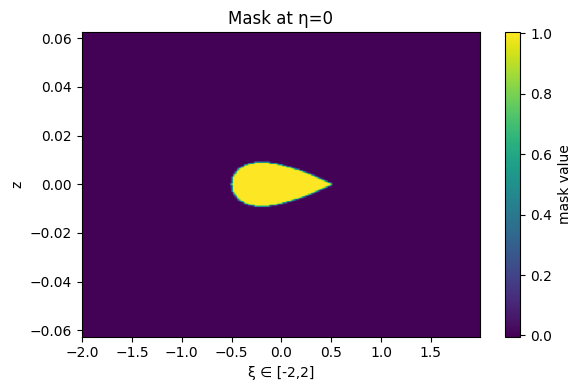

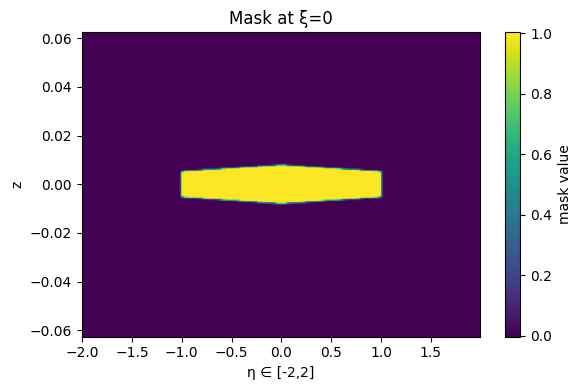

In [12]:
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mask_int[i0,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask_int[:,j0,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

In [13]:

# assumes `mask` is a NumPy array
X_np = mask.astype(np.float64)              # keep high precision if you want
#X_np = np.transpose(X_np, axes=[0, 1, 2])   # your original transpose (no-op if already)
X = tn.from_numpy(X_np).to(dtype=tn.float64)

# ── HOSVD / Tucker via SVD on unfoldings ─────────────────────────────────────
def unfold_tn(X, mode):
    # move the chosen mode to the front, then flatten the rest
    return tn.movedim(X, mode, 0).reshape(X.shape[mode], -1)

def tucker_hosvd(X, ranks):
    """
    X: (I, J, K) torch tensor
    ranks: (r1, r2, r3)
    returns: core G (r1, r2, r3), factors (U1, U2, U3) with shapes (I,r1),(J,r2),(K,r3)
    """
    I, J, K = X.shape
    r1 = min(ranks[0], I)
    r2 = min(ranks[1], J)
    r3 = min(ranks[2], K)

    U = []
    for mode, r in enumerate((r1, r2, r3)):
        M = unfold_tn(X, mode)                               # (dim_mode, prod_other_dims)
        # SVD in torch
        U_mode, S_mode, Vh_mode = tn.linalg.svd(M, full_matrices=False)
        U.append(U_mode[:, :r].contiguous())                 # (dim_mode, r)

    U1, U2, U3 = U

    # Core: G = X ×1 U1^T ×2 U2^T ×3 U3^T  (einsum form)
    # X: ijk, U1^T: ai, U2^T: bj, U3^T: ck -> abc
    G = tn.einsum('ijk,ai,bj,ck->abc', X, U1.T, U2.T, U3.T)

    return G, (U1, U2, U3)


def tucker_reconstruct(G, factors):
    U1, U2, U3 = factors
    # X_hat = G ×1 U1 ×2 U2 ×3 U3  (einsum form)
    # G: abc, U1: ia, U2: jb, U3: kc -> ijk
    X_hat = tn.einsum('abc,ia,jb,kc->ijk', G, U1, U2, U3)
    return X_hat

# ── Run HOSVD/Tucker ─────────────────────────────────────────────────────────
rt = 100
G, U = tucker_hosvd(X, ranks=(rt, rt, rt))
X_hat = tucker_reconstruct(G, U)

# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - X_hat).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Core shape: {tuple(G.shape)}")
print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")


Core shape: (100, 100, 100)
Abs L2 error: 9.213035e-13
Rel error   : 2.210758e-15


In [14]:
comb_qtt = combqtt(G,U,eps=1e-10)
#comb_qtt = qttc_from_TT(mask)
comb_c = tree_compress_2(comb_qtt,eps=1e-8)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

0.01580047607421875
0.009065032005310059
128


In [15]:
#comb_qtt = combqtt(G,U,eps=1e-10)
comb_qtt = qttc_from_TT(mask,1e-10)
comb_c = tree_compress_2(comb_qtt,eps=1e-8)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

0.00952070951461792
0.009065032005310059
128


In [16]:
comb_c = tree_compress(comb_qtt,eps=1e-5)
print(comb_comp(comb_c), comb_max_rank(comb_c))

#comb_c = tree_compress_2(comb_qtt,eps=1e-3)
#print(comb_comp(comb_c), comb_max_rank(comb_c))

0.009065032005310059 128


In [17]:
cr = combqtt_full(comb_c).numpy()
#comb = tu_to_comb(G,U,eps=1e-14)
#cr = comb_full(comb)
#print(cr.shape)


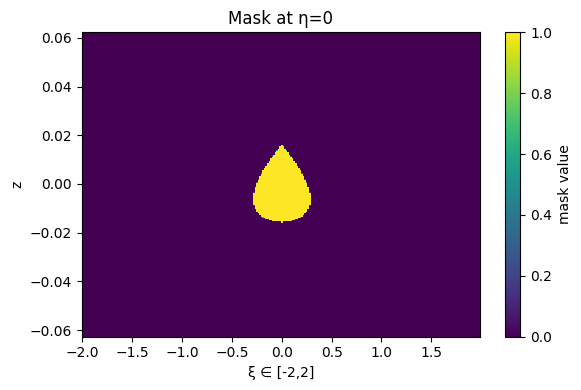

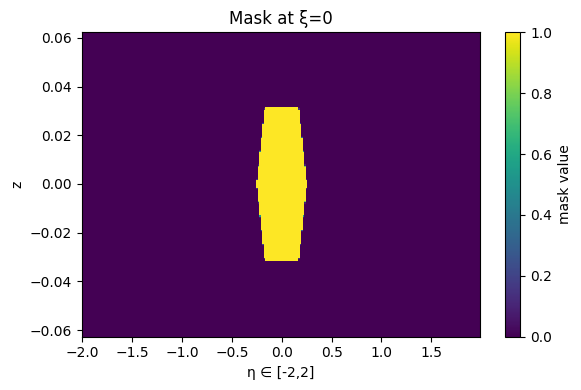

Abs L2 error: 4.421790e-07
Rel error   : 1.061052e-09


/tmp/ipykernel_1104740/2349370251.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err_abs = tn.linalg.norm((X - cr).reshape(-1)).item()


In [18]:
eta_vals = np.linspace(-2,  2, 2**8, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**8, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**8, endpoint=False)
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, cr[i0,:,:], shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, cr[:,j0,:], shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()


# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - cr).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")

In [19]:
comb = tu_to_comb(G,U,eps=1e-10)
combf_com= comb_comp(comb)
print(combf_com)
print(comb_max_rank(comb))
comb_c = tree_compress(comb,eps=1e-3)
print(comb_comp(comb_c))


0.012832880020141602
100
0.007153928279876709


0.00014519598335027695


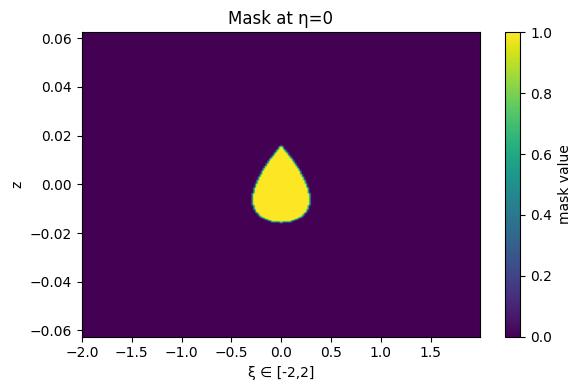

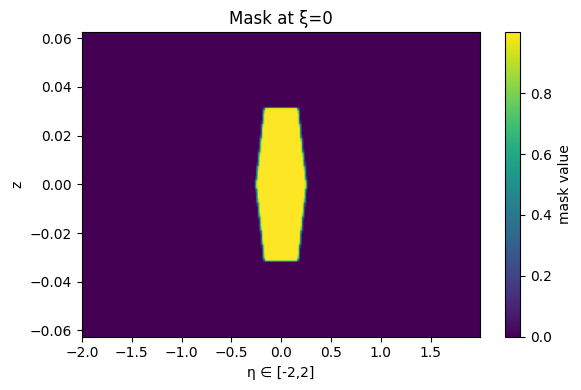

In [20]:
fd = 10 
extcqttb = comb_interpolate_p(comb_qtt,fd, eps =  1e-4,order = 2)

print(comb_comp(extcqttb))

full = combqtt_full(extcqttb).numpy()

eta_vals = np.linspace(-2,  2, 2**fd, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**fd, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**fd, endpoint=False)
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, full[i0,:,:], shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, full[:,j0,:], shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()



In [21]:
from time import time
for i in range(9,14):
    t1 = time()
    cmask = comb_interpolate_p(comb_qtt, i, eps =  1e-4,order = 2)
    t2 = time()
    print(f"Time for comb interp to 2**{i}: {t2-t1:.2f} sec")
    print("\033[91m" + str(i) + ", " + f"{comb_comp(cmask):.3e}" + " , " + str(comb_max_rank(cmask)) + "\033[0m")

    t1 = time()
    zmask = qtt_skcubic3d_p(qttmask, i, eps = 1e-4, order=2)
    t2 = time()
    print(f"Time for QTT interp to 2**{i}: {t2-t1:.2f} sec")
    print("\033[94m" + str(i) + ", " + f"{tt_comp(zmask):.3e}" + " , " + str(np.max(zmask.R)) + "\033[0m")

Time for comb interp to 2**9: 0.15 sec
9, 1.160e-03 , 129
Time for QTT interp to 2**9: 6.55 sec
9, 1.210e-02 , 525
Time for comb interp to 2**10: 0.14 sec
10, 1.452e-04 , 129
Time for QTT interp to 2**10: 7.33 sec
10, 1.838e-03 , 583
Time for comb interp to 2**11: 0.17 sec
11, 1.816e-05 , 129
Time for QTT interp to 2**11: 7.27 sec
11, 2.383e-04 , 594
Time for comb interp to 2**12: 0.15 sec
12, 2.271e-06 , 129
Time for QTT interp to 2**12: 7.27 sec
12, 3.012e-05 , 598
Time for comb interp to 2**13: 0.18 sec
13, 2.840e-07 , 129
Time for QTT interp to 2**13: 7.38 sec
13, 3.804e-06 , 601


In [22]:
qtt_R_max = int(np.round(np.max(qttmask.R)))
qtt_erank = int(np.round(erank(qttmask.R, qttmask.N)))
qtt_comp  = tt_comp(qttmask)
tt_R_max   = int(np.round(np.max(ttmask.R)))
tt_erank   = int(np.round(erank(ttmask.R, ttmask.N)))
tt_com   = tt_comp(ttmask)

# Use ANSI escape sequences to color the outputs (red for qtt, blue for tt)
print("\033[91mqtt_R_max =", qtt_R_max, "\033[0m")
print("\033[91mqtt_erank =", qtt_erank, "\033[0m")
print("\033[91mqtt_comp  =", qtt_comp, "\033[0m")
print("\033[94mtt_R_max =", tt_R_max, "\033[0m")
print("\033[94mtt_erank =", tt_erank, "\033[0m")
print("\033[94mtt_comp  =", tt_com, "\033[0m")

print("\033[92mmrank_cqtt =", mrank_cqtt, "\033[0m")
print("\033[92mcomp_combqtt =", comp_combqtt, "\033[0m")

print("\033[95mcombf_com =", combf_com, "\033[0m")



qtt_R_max = 327 
qtt_erank = 102 
qtt_comp  = 0.02710092067718506 
tt_R_max = 271 
tt_erank = 148 
tt_comp  = 0.05710911750793457 
mrank_cqtt = 128 
comp_combqtt = 0.00952070951461792 
combf_com = 0.012832880020141602 


In [8]:

from src.qtt_interpolation.utils import *
from src.qtt_interpolation.int_tools import *
from metrics.mutils import *

import teneva as ten
from time import time


def ften3d(I,a,b):
    X = ind_to_r_g(I,a=a,b=b,d=3,pdp=1)
    z,y,x = X[:,0], X[:,1], X[:,2]
    return wing_mask_pc( tn.tensor(x,dtype=tn.float64), tn.tensor(y,dtype=tn.float64),tn.tensor(z,dtype=tn.float64))

f = lambda I : ften3d(I,a=[-zlim,-2,-2],b=[zlim,2,2])

#------------------

p_coarse =8
zlim     = 1/16
num_points = 2**p_coarse
pmax = 9
reps = 2
mode = []
scale  = []
error = []
T= []
rmax, ernk = [], []

for p in range(p_coarse+1, pmax+1):


    print(p,pmax, flush=True)
    #get statistics for cross
    for i in range(reps):

        # SVD coarse interleaved
        t = time()
        x = np.linspace(-2,  2, 2**p_coarse, endpoint=False)  # ← extended from [-1,1]
        y   = np.linspace(-2,  2, 2**p_coarse, endpoint=False)
        z   = np.linspace(-zlim, zlim, 2**p_coarse, endpoint=False)
        X, Y, Z = np.meshgrid(x, y,z, indexing='ij')

        mask_grid = wing_mask(X,Y,Z)
        mask_svd = tntt.TT(zM3(mask_grid,p_coarse),[2,2,2]*p_coarse,eps=1e-10)
        t_mask = time() - t

        # TT cross interleaved
        ncoarse = [ 2,2,2]*p_coarse
        m         = None  # Number of calls to target function
        e         =  1e-7   # Desired accuracy
        nswp      = 4   # Sweep number
        r         = 10      # TT-rank of the initial tensor
        dr_min    = 2      # Cross parameter (minimum number of added rows)
        dr_max    = 5      # Cross parameter (maximum number of added rows)

        
        Yc = ten.rand(ncoarse, r)
        cache,info_coarse = {}, {}
        mask_ttc = ten.cross(f, Yc, m, e, nswp, dr_min=dr_min, dr_max=dr_max,log=True,cache=cache,m_cache_scale=5,info=info_coarse)
        mask_ttc = ten.truncate(mask_ttc,1e-12)

        # do the interpolation
        t = time()
        mask_svd_i = qtt_skcubic3d_p(mask_svd, p, eps = 1e-3, order=1)
        t_svd_i = time() - t
        #mask_svd_i = [c.numpy() for c in mask_svd_i.cores]

        t = time()
        mask_ttc_i = qtt_skcubic3d_p( tntt.TT([tn.tensor(c,dtype=tn.float64) for c in mask_ttc]) ,p, eps=1e-3, order=1)
        t_ttc_i = time() - t
        #mask_ttc_i = [c.numpy() for c in mask_ttc_i.cores]

        #cross over the fine grid

        n = [ 2,2,2]*p   # Shape of the tensor
        m         = None  # Number of calls to target function
        e         =  1e-4  # Desired accuracy
        nswp      = 3   # Sweep number
        r         = 10 + (p-p_coarse)*2      # TT-rank of the initial tensor
        dr_min    = 2      # Cross parameter (minimum number of added rows)
        dr_max    = 5      # Cross parameter (maximum number of added rows)

        Y = ten.rand(n, r)
        info_fine,cache = {}, {}
        Y = ten.cross(f, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max, cache=cache,m_cache_scale=5,log=True,info=info_fine)
        Yr = ten.truncate(Y, 1e-3) 

        ''' 
        #validate over 1e5 points
        m_tst = int(1e5)
        # Random multi-indices for the test points:
        I_tst = np.vstack([np.random.choice(k, m_tst) for k in n]).T
        y_tst = f(I_tst)
        norm = np.linalg.norm(y_tst)

        y_tt = ten.get_many(Yr, I_tst)
        e_tst = np.linalg.norm(y_tt - y_tst) / norm

        y_tti = ten.get_many(mask_ttc_i, I_tst)
        e_tstti = np.linalg.norm(y_tti - y_tst) / norm
    
        y_tti_svd = ten.get_many(mask_svd_i, I_tst)
        e_tstti_svd = np.linalg.norm(y_tti - y_tst) / norm
        print('errors', e_tst,e_tstti,e_tstti_svd)
        '''
        print('doing errors...',flush=True)
        Nsamples = int(50000)
        a = [-zlim,-2,-2]
        b = [zlim,2,2]

        samp = tt_mc_sample(mask_svd_i.cores, Nsamples, rng = None, return_joint=False)
        vals = mask_svd.apply_mask(samp.T)
        x = (b[0]-a[0])*(samp.T[:,0::3] * tn.tensor([2**(-i-1) for i in range(p)])).sum(1) + a[0]
        y = (b[1]-a[1])*(samp.T[:,1::3] * tn.tensor([2**(-1-i) for i in range(p)])).sum(1) + a[1]
        z = (b[2]-a[2])*(samp.T[:,2::3] * tn.tensor([2**(-1-i) for i in range(p)])).sum(1) + a[2]
        e_tstti_svd = ( ( tn.from_numpy(wing_mask_pc(z,y,x))-vals)**2 ).sum()/Nsamples
        print('first samples',flush=True)
        samp = tt_mc_sample(mask_ttc_i.cores, Nsamples, rng = None, return_joint=False)
        vals = mask_ttc_i.apply_mask(samp.T)
        x = (b[0]-a[0])*(samp.T[:,0::3] * tn.tensor([2**(-i-1) for i in range(p)])).sum(1) + a[0]
        y = (b[1]-a[1])*(samp.T[:,1::3] * tn.tensor([2**(-1-i) for i in range(p)])).sum(1) + a[1]
        z = (b[2]-a[2])*(samp.T[:,2::3] * tn.tensor([2**(-1-i) for i in range(p)])).sum(1) + a[2]
        e_tstti = (( tn.from_numpy(wing_mask_pc(z,y,x))-vals)**2).sum()/Nsamples
        print('second samples',flush=True)
        samp = tt_mc_sample([tn.from_numpy(c) for c in Yr], Nsamples, rng = None, return_joint=False)
        vals = ten.act_one.get_many(Yr,samp.T)
        x = (b[0]-a[0])*(samp.T[:,0::3] * tn.tensor([2**(-i-1) for i in range(p)])).sum(1) + a[0]
        y = (b[1]-a[1])*(samp.T[:,1::3] * tn.tensor([2**(-1-i) for i in range(p)])).sum(1) + a[1]
        z = (b[2]-a[2])*(samp.T[:,2::3] * tn.tensor([2**(-1-i) for i in range(p)])).sum(1) + a[2]
        e_tst =np.sum( (wing_mask_pc(z,y,x)-vals)**2)/Nsamples
        print('third samples',flush=True)

        # Save only the last 3 entries: 'cross', 'cross_int', 'svd_int'
        mode.extend(['cross', 'cross_int', 'svd_int'])
        scale.extend([p, p, p])
        error.extend([e_tst.item(), e_tstti.item(), e_tstti_svd.item()])
        T.extend([info_fine['t'], t_ttc_i + info_coarse['t'], t_svd_i + t_mask])
        rmax.extend([
            np.max(ten.ranks(Yr)),
            np.max(mask_ttc_i.R),
            np.max(mask_svd_i.R)
        ])
        ernk.extend([
            tt_comp(Yr),
            tt_comp(mask_ttc_i),
            tt_comp(mask_svd_i)
        ])

        print((i+1)/reps, end='\r', flush=True)

        # Save the last 3 rows as JSON lines
        for j in range(-3, 0):
            raw_row = {
            'method': mode[j],
            'scale':  scale[j],
            'error':  error[j],
            'time':   T[j],
            'rmax':   rmax[j],
            'erank':  ernk[j]
            }
            # Convert any Tensor or NumPy scalar to plain Python

            ''' 
            safe_row = {}
            for k, v in raw_row.items():
                if isinstance(v, tn.Tensor):
                    safe_row[k] = v.item() if v.numel() == 1 else v.tolist()
                elif isinstance(v, np.generic):
                    safe_row[k] = v.item()
                else:
                    safe_row[k] = v

            with open(jsonl_path, 'a') as f:
                f.write(json.dumps(safe_row) + '\n')
                f.flush()
                os.fsync(f.fileno())
            '''

        print(f"  rep {i+1}/{reps} saved", end='\r', flush=True)

9 9
# pre | time:      0.010 | evals: 0.00e+00 (+ 0.00e+00) | rank:  10.0 | 
#   1 | time:      0.290 | evals: 5.10e+03 (+ 6.25e+03) | rank:  14.2 | e: 1.0e+00 | 
#   2 | time:      1.296 | evals: 1.30e+04 (+ 2.39e+04) | rank:  20.2 | e: 5.5e-01 | 
#   3 | time:      4.393 | evals: 2.68e+04 (+ 5.80e+04) | rank:  26.6 | e: 5.6e-01 | 
#   4 | time:      9.813 | evals: 4.66e+04 (+ 1.17e+05) | rank:  33.3 | e: 6.0e-01 | stop: nswp | 
# pre | time:      0.019 | evals: 0.00e+00 (+ 0.00e+00) | rank:  12.0 | 
#   1 | time:      0.618 | evals: 8.36e+03 (+ 9.86e+03) | rank:  16.6 | e: 1.0e+00 | 
#   2 | time:      2.929 | evals: 2.28e+04 (+ 3.49e+04) | rank:  23.5 | e: 7.5e-01 | 
#   3 | time:      8.039 | evals: 4.67e+04 (+ 8.29e+04) | rank:  30.4 | e: 8.0e-01 | stop: nswp | 
doing errors...
first samples
second samples
third samples
# pre | time:      0.010 | evals: 0.00e+00 (+ 0.00e+00) | rank:  10.0 | 
#   1 | time:      0.372 | evals: 4.95e+03 (+ 6.57e+03) | rank:  14.2 | e: 1.0e+00 | 
#   

/tmp/ipykernel_1117574/1702900280.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rgba[:, 3] = (mg).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0


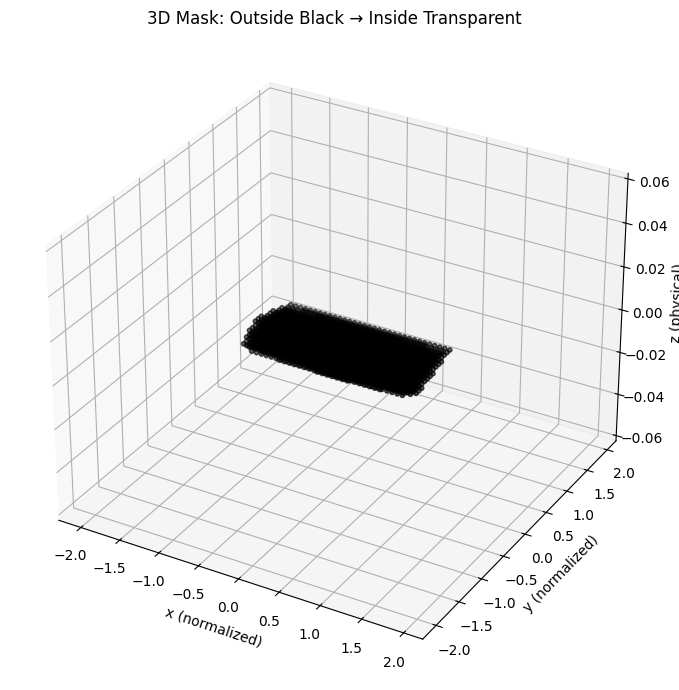

In [9]:
mg = z_order_to_normal_3d(tntt.TT([tn.from_numpy(c) for c in Yr]).full().flatten(),2**p,2**p,2**p).T
x = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
y   = np.linspace(-2,  2, 2**p, endpoint=False)
z   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
X, Y, Z = np.meshgrid(x, y,z, indexing='ij')
# --- Invert alpha: alpha = 1 - mask ---
rgba = np.zeros(((mg.numpy().size), 4))
rgba[:, 3] = (mg).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0
# Min-max normalization of alpha channel (rgba[:, 3]) to [0, 1]
rgba = np.clip(rgba, 0, 1)

# Plot 3D scatter with transparency
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X.ravel(), Y.ravel(), Z.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
df = pd.DataFrame({
    'method': mode,
    'scale': scale,
    'error': error,
    'time': T,
    'rmax': rmax,
    'erank': ernk
})
df['rmse'] = np.sqrt(df['error'])
df

,method,scale,error,time,rmax,erank,rmse
0,cross,9,0.134576,8.038823,41,0.000288,0.366846
1,cross_int,9,0.097481,11.339314,297,0.006862,0.312219
2,svd_int,9,0.009200,9.585479,452,0.009412,0.095917
3,cross,9,0.205429,7.655807,41,0.000285,0.453243
4,cross_int,9,0.082601,11.975364,285,0.006887,0.287404
5,svd_int,9,0.009300,9.376193,452,0.009412,0.096437


In [156]:
Nsamples = int(1e4)
mask_svd = mask_ttc_i
samp = tt_mc_sample(mask_svd.cores, Nsamples, rng = None, return_joint=False)
vals = mask_svd.apply_mask(samp.T)
a = [-zlim,-2,-2]
b = [zlim,2,2]
x = (b[0]-a[0])*(samp.T[:,0::3] * tn.tensor([2**(-i-1) for i in range(pmax)])).sum(1) + a[0]
y = (b[1]-a[1])*(samp.T[:,1::3] * tn.tensor([2**(-1-i) for i in range(pmax)])).sum(1) + a[1]
z = (b[2]-a[2])*(samp.T[:,2::3] * tn.tensor([2**(-1-i) for i in range(pmax)])).sum(1) + a[2]
(( tn.from_numpy(wing_mask_pc(z,y,x))-vals)**2/Nsamples).sum()

tensor(0.0726, dtype=torch.float64)

In [153]:
Nsamples = int(1e4)
pmax = 10
ibs = 12
mask_svd = tntt.TT([tn.tensor(c,dtype=tn.float64) for c in Yr],eps=1e-14)
mask_svd = mask_svd
samp = tt_mc_sample_bo(mask_svd.cores,ibs, Nsamples, rng = None, return_joint=False)
samp = bin_bits(samp.T,ibs).T
vals = mask_svd.apply_mask(samp.T)
a = [-zlim,-2,-2]
b = [zlim,2,2]
x = (b[0]-a[0])*(samp.T[:,0::3] * tn.tensor([2**(-i-1) for i in range(pmax)])).sum(1) + a[0]
y = (b[1]-a[1])*(samp.T[:,1::3] * tn.tensor([2**(-1-i) for i in range(pmax)])).sum(1) + a[1]
z = (b[2]-a[2])*(samp.T[:,2::3] * tn.tensor([2**(-1-i) for i in range(pmax)])).sum(1) + a[2]
(( tn.from_numpy(wing_mask_pc(z,y,x))-vals)).norm()/np.sqrt(Nsamples)

tensor(0.4321, dtype=torch.float64)

In [63]:
mask_svd.apply_mask(samp.T)

tensor([1.1683, 1.3898, 1.6974,  ..., 1.0084, 1.3159, 0.9877],
       dtype=torch.float64)

In [62]:
vals = ten.act_one.get_many(Yr,samp.T)
(( tn.from_numpy(wing_mask_pc(z,y,x))- tn.from_numpy(vals))**2/Nsamples).sum().sqrt()

tensor(0.6707, dtype=torch.float64)

In [77]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def scatter3d(x, y, z, s=4, alpha=0.7):
    # accept torch tensors or array-likes
    to_np = lambda a: a.detach().flatten().cpu().numpy() if hasattr(a, "detach") else np.asarray(a).ravel()
    x, y, z = to_np(x), to_np(y), to_np(z)
    assert x.size == y.size == z.size, "x,y,z must have same length"

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, s=s, alpha=alpha)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2,2)
    ax.set_zlim(-zlim, zlim)

    plt.tight_layout()
    return fig, ax


(<Figure size 600x600 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

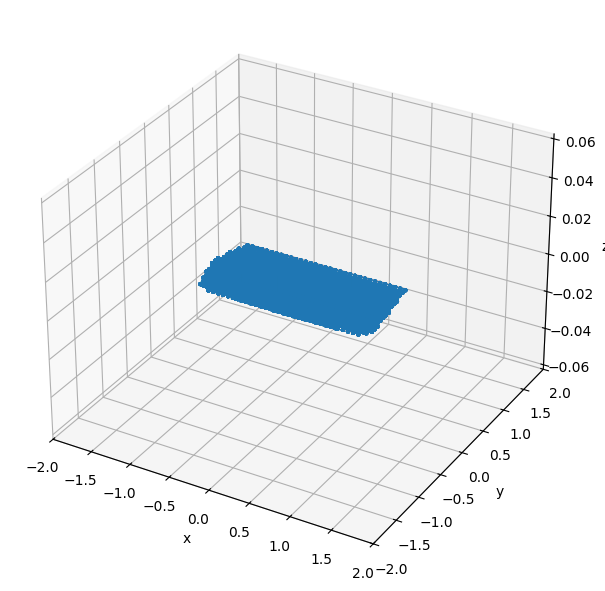

In [20]:
scatter3d(z, y, x, s=4, alpha=0.7)

In [9]:
from src.qtt_interpolation.comb import *

In [10]:
def _clone_comb(comb):
    new = []
    for branch in comb:
        new_branch = []
        for t in branch:
            new_branch.append(t.clone())
        new.append(new_branch)
    return new

def fuse_root(root):

    return tn.einsum('abc,cde,efg -> bdf', *root)

def marginal_probs_comb(core, Tprev, l_index):
    if l_index == 0:
        ampls = tn.einsum('nijk,iax->naxjk', Tprev, core)
    elif l_index == 1:
        ampls = tn.einsum('nijk,jax->naixk', Tprev, core)
    else:
        ampls = tn.einsum('nijk,kax->naijx', Tprev, core)
    probs = (ampls**2).sum(dim=(2,3,4))
    return probs

def marginal_probs_comb_rw(row, Tprev):

    ampls = tn.einsum('nijk,iax,jby,kcz->nabcxyz', Tprev, row[0],row[1],row[2]).flatten(1,3)
    probs = (ampls**2).sum(dim=(2,3,4))
    return probs

def sample_r(probs, rng, sentinel=-1):
    p = probs.clamp_min(0)
    sums = p.sum(dim=1); nz = sums > 0
    out = tn.full((p.size(0),), sentinel, device="cpu")
    if nz.any():
        if rng is None:
            rng = tn.Generator(device="cpu").seed()
        out[nz] = tn.multinomial(p[nz], 1, replacement=True, generator=rng).squeeze(1)
    return out

def sample_from_comb(comb, Nsamples, rng = None, return_joint=False):

    if rng == None:
        rng = ensure_torch_rng()

    D = len(comb)
    L = len(comb[0])
    combc = _clone_comb(comb)
    #right orthogonalize the cores

    for i in range(D):
        combc[i] = rcf(combc[i])
    
    root =  get_roott(combc)
    fr = fuse_root(root)

    # first_core
    c0x = combc[0][1]
    mps0 = tn.einsum('abc,axy -> bcxy',c0x,fr)

    p0 = (mps0**2).sum(dim=(1,2,3))
    p0 = tn.clamp(p0, min=0)
    p0 /= p0.sum()
    print(p0)
    first_samples = tn.multinomial(p0, num_samples=Nsamples,replacement=True, generator=rng)
    Tprev = mps0[first_samples]        # (Nsamples, D1)
    prob_prev = (Tprev**2).sum(dim=(1,2,3))        # current accumulated probability
    bitstrings = first_samples.reshape(1, Nsamples)
    # iterate over rows
    for j in range(1,L):

        for k in range(3):
            #skip first core
            if j == 1 and k == 0:
                pass
            else:
                cur_core = combc[k][j]
                probs_cur = marginal_probs_comb(cur_core,Tprev,k)
                probs_cond = probs_cur / prob_prev[:, None]
                samples_site = sample_r(probs_cond, rng)
                Tsite = cur_core[:,samples_site,:]   
                if k == 0:
                    Tprev = tn.einsum('nijk,inx->nxjk', Tprev, Tsite)
                elif k == 1:
                    Tprev = tn.einsum('nijk,jnx->nixk', Tprev, Tsite)
                else:
                    Tprev = tn.einsum('nijk,knx->nijx', Tprev, Tsite)
                prob_prev = (Tprev**2).sum(dim=(1,2,3))  
                bitstrings = tn.concatenate((bitstrings, samples_site.reshape(1, Nsamples)), axis=0)

    if return_joint:
        return bitstrings, prob_prev

    return bitstrings

def ints_to_bits_concat(a, bits=None, msb_first=True):
    """
    a: tensor of nonnegative ints (any shape)
    bits: number of bits; if None, picked from max(a)
    msb_first: True -> [MSB ... LSB], False -> [LSB ... MSB]
    Returns:
      B: per-value bit tensor with an extra last dim of length `bits`
      concat_1d: all bits flattened into a single 1D tensor
    """
    a = tn.as_tensor(a, dtype=tn.long)
    maxv = int(a.max().item()) if a.numel() > 0 else 0
    bits = max(1, (maxv.bit_length() if bits is None else bits))

    if msb_first:
        shifts = tn.arange(bits-1, -1, -1, device=a.device)
    else:
        shifts = tn.arange(bits, device=a.device)

    B = ((a[..., None] >> shifts) & 1).to(a.dtype)  # shape: a.shape + (bits,)
    return B


def sample_from_comb_rw(comb, Nsamples, rng = None, return_joint=False):

    if rng == None:
        rng = ensure_torch_rng()

    D = len(comb)
    L = len(comb[0])
    combc = _clone_comb(comb)
    #right orthogonalize the cores

    for i in range(D):
        combc[i] = rcf(combc[i])
    
    root =  get_roott(combc)
    fr = fuse_root(root)

    # first_row
    r0 = [combc[i][1] for i in range(3)]
    mps0 = tn.einsum('xyz,xna,ymb,zlc -> nmlabc',fr,r0[0],r0[1],r0[2]).flatten(0,2)

    p0 = (mps0**2).sum(dim=(1,2,3))
    p0 = tn.clamp(p0, min=0)
    p0 /= p0.sum()
    print(p0)
   
    first_samples = tn.multinomial(p0, num_samples=Nsamples,replacement=True, generator=rng)
    print(first_samples)
    Tprev = mps0[first_samples]        # (Nsamples, D1)
    prob_prev = (Tprev**2).sum(dim=(1,2,3))        # current accumulated probability
    bitstrings = first_samples.reshape(1, Nsamples)

    # iterate over rows
    for j in range(2,L):

        cur_row = [combc[i][j] for i in range(3)]
        probs_cur = marginal_probs_comb_rw(cur_row,Tprev)
        probs_cond = probs_cur / prob_prev[:, None]
        samples_site = sample_r(probs_cond, rng)
 
        c_samples = ints_to_bits_concat(samples_site, bits=3, msb_first=True).T
        Trow = [cur_row[i][:,c_samples[i],:] for i in range(3)] 
        Tprev = tn.einsum('nxyz,xna,ynb,znc -> nabc',Tprev,Trow[0],Trow[1],Trow[2])
        prob_prev = (Tprev**2).sum(dim=(1,2,3))  
        bitstrings = tn.concatenate((bitstrings, samples_site.reshape(1, Nsamples)), axis=0)

    if return_joint:
        return bitstrings, prob_prev

    return bitstrings

def marginal_probs_cw(core, Tprev,):

    ampls = tn.einsum('ncz,cmy->nmyz', Tprev, core)
    probs = (ampls**2).sum(dim=(2,3))
    return probs

def sample_from_comb_cw(comb, Nsamples, rng = None, return_joint=False):

    if rng == None:
        rng = ensure_torch_rng()

    D = len(comb)
    L = len(comb[0])
    combc = _clone_comb(comb)
    #right orthogonalize the cores

    for i in range(D):
        combc[i] = rcf(combc[i])
    
    root =  rcf(get_roott(combc))
    update_comb(combc,root)

    #first column
    mps0 = tn.einsum('xyz,ybc -> bcz',root[0],combc[0][1])
    p0 = (mps0**2).sum(dim=(1,2))
    p0 = tn.clamp(p0, min=0)
    p0 /= p0.sum()
    first_samples = tn.multinomial(p0, num_samples=Nsamples,replacement=True, generator=rng)
    Tprev = mps0[first_samples]        # (Nsamples, D1)
    prob_prev = (Tprev**2).sum(dim=(1,2))        # current accumulated probability
    bitstrings = first_samples.reshape(1, Nsamples)

    # iterate over rows
    for j in range(2,L):
        cur= combc[0][j] 
        probs_cur = marginal_probs_cw(cur,Tprev)
        probs_cond = probs_cur / prob_prev[:, None]
        samples_site = sample_r(probs_cond, rng)
        Trow = cur[:,samples_site,:]
        Tprev = tn.einsum('ncz,cny -> nyz',Tprev,Trow)
        prob_prev = (Tprev**2).sum(dim=(1,2))  
        bitstrings = tn.concatenate((bitstrings, samples_site.reshape(1, Nsamples)), axis=0)

    #other branches
    for i in range(1,3):
        Tprev = tn.einsum('ncz,zay->nay',Tprev,root[i])

        for j in range(1,L):
            cur= combc[i][j] 
            probs_cur = marginal_probs_cw(cur,Tprev)
            probs_cond = probs_cur / prob_prev[:, None]
            samples_site = sample_r(probs_cond, rng)
            Trow = cur[:,samples_site,:]
            Tprev = tn.einsum('ncz,cny -> nyz',Tprev,Trow)
            prob_prev = (Tprev**2).sum(dim=(1,2))  
            bitstrings = tn.concatenate((bitstrings, samples_site.reshape(1, Nsamples)), axis=0)

    if return_joint:
        return bitstrings, prob_prev

    return bitstrings




In [16]:
comb_qtt = qttc_from_TT(mask_grid ,1e-10)

/tmp/ipykernel_1117574/1239747938.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rgba[:, 3] = (mg).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0


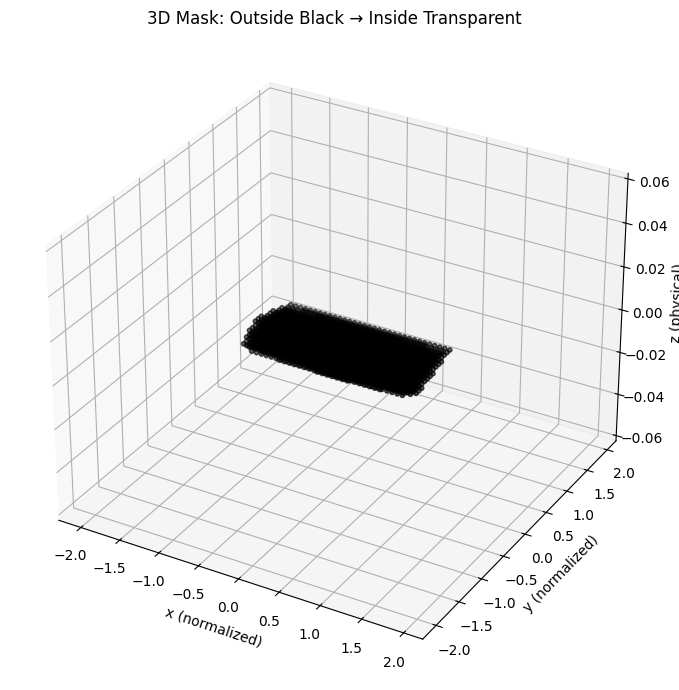

In [28]:
#mg = tntt.TT(mask_grid_f).full()
mg = combqtt_full(comb_qtt)
x = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
y   = np.linspace(-2,  2, 2**p, endpoint=False)
z   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
X, Y, Z = np.meshgrid(x, y,z, indexing='ij')
# --- Invert alpha: alpha = 1 - mask ---
rgba = np.zeros(((mg.numpy().size), 4))
rgba[:, 3] = (mg).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0
# Min-max normalization of alpha channel (rgba[:, 3]) to [0, 1]
rgba = np.clip(rgba, 0, 1)

# Plot 3D scatter with transparency
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X.ravel(), Y.ravel(), Z.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [148]:
from src.qtt_interpolation.utils import *
from src.qtt_interpolation.int_tools import *
from metrics.mutils import *

p=9
zlim     = 1/16
x = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
y   = np.linspace(-2,  2, 2**p, endpoint=False)
z   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
X, Y, Z = np.meshgrid(x, y,z, indexing='ij')
mask_grid = wing_mask(X,Y,Z)
comb_qtt = qttc_from_TT(mask_grid ,1e-12)

In [149]:
comb_qtt = comb_interpolate_p(comb_qtt,p+1, eps =  1e-3,order = 2)

In [150]:
Nsamples=30000
smaps = sample_from_comb_cw(comb_qtt,Nsamples).reshape(3,p+1,-1)
a = [-2,-2,-zlim]
b = [2,2,zlim]
x = (b[0]-a[0])*((smaps[0].T)*tn.tensor([2**(-i-1) for i in range(p+1)])).sum(1) + a[0]
y = (b[1]-a[1])*((smaps[1].T)*tn.tensor([2**(-i-1) for i in range(p+1)])).sum(1) + a[1]
z = (b[2]-a[2])*((smaps[2].T)*tn.tensor([2**(-i-1) for i in range(p+1)])).sum(1) + a[2]
c_mask = apply_mask_c(comb_qtt,smaps,sample_type='column')

( tn.from_numpy(wing_mask_pc(x,y,z))-c_mask).norm()/np.sqrt(Nsamples)

tensor(0.0494, dtype=torch.float64)

In [100]:
cf = combqtt_full(comb_qtt)

In [101]:
x = np.linspace(-2,  2, 2**(p+2), endpoint=False)  # ← extended from [-1,1]
y   = np.linspace(-2,  2, 2**(p+2), endpoint=False)
z   = np.linspace(-zlim, zlim, 2**(p+2), endpoint=False)
X, Y, Z = np.meshgrid(x, y,z, indexing='ij')
mask_gridf = wing_mask(X,Y,Z)

In [102]:
((cf-mask_gridf)**2).mean()

tensor(0.0004, dtype=torch.float64)

(<Figure size 600x600 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='y', zlabel='z'>)

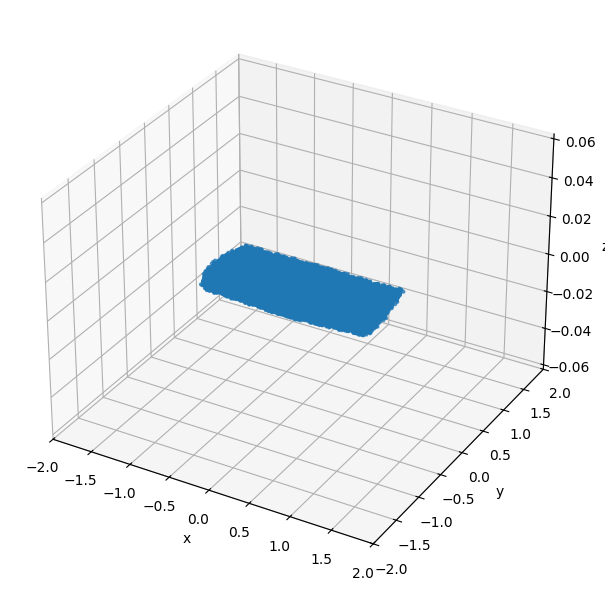

In [78]:
scatter3d(x, y, z, s=4, alpha=0.7)

In [ ]:

pmax=len(comb_qtt[0])-1
a = [-2,-2,-zlim]
b = [2,2,zlim]
s_type = 'row'
Nsamples=100
if s_type =='row':
    samps = sample_from_comb_rw(comb_qtt,Nsamples)
    bsamps = ints_to_bits_concat(samps, bits=3, msb_first=True).T
    x = (b[0]-a[0])*(bsamps[0]*tn.tensor([2**(-i-1) for i in range(pmax)])).sum(1) + a[0]
    y = (b[1]-a[1])*(bsamps[1]*tn.tensor([2**(-i-1) for i in range(pmax)])).sum(1) + a[1]
    z = (b[2]-a[2])*(bsamps[2]*tn.tensor([2**(-i-1) for i in range(pmax)])).sum(1) + a[2]
else:
    print('seq')
    samp = sample_from_comb(comb_qtt,Nsamples)
    x = (b[0]-a[0])*(samp.T[:,0::3] * tn.tensor([2**(-i-1) for i in range(pmax)])).sum(1) + a[0]
    y = (b[1]-a[1])*(samp.T[:,1::3] * tn.tensor([2**(-1-i) for i in range(pmax)])).sum(1) + a[1]
    z = (b[2]-a[2])*(samp.T[:,2::3] * tn.tensor([2**(-1-i) for i in range(pmax)])).sum(1) + a[2]



#fig,ax = scatter3d(x, y, z, s=4, alpha=1)


tensor([0.1483, 0.1602, 0.0873, 0.0995, 0.1512, 0.1632, 0.0890, 0.1014],
       dtype=torch.float64)
tensor([4, 3, 6, 7, 6, 7, 4, 2, 1, 0, 5, 4, 6, 5, 1, 1, 5, 4, 7, 5, 0, 5, 2, 3,
        5, 3, 4, 3, 6, 0, 7, 2, 2, 7, 0, 5, 4, 6, 4, 5, 4, 6, 5, 5, 4, 5, 4, 0,
        5, 1, 5, 5, 5, 6, 0, 0, 0, 0, 3, 7, 1, 1, 0, 5, 2, 7, 5, 0, 6, 0, 0, 5,
        2, 5, 1, 5, 6, 3, 7, 6, 7, 1, 3, 7, 0, 2, 1, 3, 5, 3, 5, 0, 2, 6, 7, 3,
        0, 4, 5, 1])


In [56]:
def apply_mask_b(branch, indices):
    d = len(branch) -1 
    M = len(indices)

    result = tn.ones((1,M), dtype=tn.float64)
    for i in range(d,0,-1):
        result = tn.einsum('jik,ki->ji',branch[i][:,indices[:,i-1],:],result)

    return tn.squeeze(result)

def apply_mask_c(comb,samples, sample_type='row'):

    root = get_roott(comb)
    #fr = fuse_root(root)
    if sample_type == 'row':
        bsamps = ints_to_bits_concat(samples, bits=3, msb_first=True).T
        mx = apply_mask_b(comb[0], bsamps[0]) 
        my = apply_mask_b(comb[1], bsamps[1]) 
        mz = apply_mask_b(comb[2], bsamps[2]) 
        r1 = tn.einsum('abc, bx -> axc', root[0],mx)
        r2 = tn.einsum('abc, bx -> axc', root[1],my)
        r3 = tn.einsum('abc, bx -> axc', root[2],mz)
        return tn.einsum('uxv,vxw,wxy ->x',r1,r2,r3)
        
    elif sample_type== 'seq':
        mx = apply_mask_b(comb[0], samples.T[:,0::3]) 
        my = apply_mask_b(comb[1], samples.T[:,1::3]) 
        mz = apply_mask_b(comb[2], samples.T[:,2::3]) 
        r1 = tn.einsum('abc, bx -> axc', root[0],mx)
        r2 = tn.einsum('abc, bx -> axc', root[1],my)
        r3 = tn.einsum('abc, bx -> axc', root[2],mz)
        return tn.einsum('uxv,vxw,wxy ->x',r1,r2,r3)
    
    elif sample_type == 'column':
        samples = samples.reshape(3,len(comb[0])-1,-1)
        mx = apply_mask_b(comb[0], samples[0].T) 
        my = apply_mask_b(comb[1], samples[1].T) 
        mz = apply_mask_b(comb[2], samples[2].T) 
        r1 = tn.einsum('abc, bx -> axc', root[0],mx)
        r2 = tn.einsum('abc, bx -> axc', root[1],my)
        r3 = tn.einsum('abc, bx -> axc', root[2],mz)
        return tn.einsum('uxv,vxw,wxy ->x',r1,r2,r3)
    

c_mask = apply_mask_c(comb_qtt,smaps,sample_type='column')

( tn.from_numpy(wing_mask_pc(x,y,z))-c_mask).abs().sum()/Nsamples

tensor(0.0174, dtype=torch.float64)

In [78]:
mx.shape

torch.Size([64, 100])

In [79]:
root = get_roott(comb_qtt)

In [80]:
apply_mask_c(comb_qtt,samps, sample_type='row')

AssertionError: comb[0][0] must be 3D, got (64, 64)

In [36]:
t_comb = []
err_comb = []
mr_comb= []
s_comb = []
m_comb = []
comp_c = []
for p in range(p_coarse+1,pmax+1):
    print(p)
    for _ in range(reps):
        t = time()
        x = np.linspace(-2,  2, 2**p_coarse, endpoint=False)  # ← extended from [-1,1]
        y   = np.linspace(-2,  2, 2**p_coarse, endpoint=False)
        z   = np.linspace(-zlim, zlim, 2**p_coarse, endpoint=False)
        X, Y, Z = np.meshgrid(x, y,z, indexing='ij')

        mask_grid = wing_mask(X,Y,Z)
        t_mask = time() - t

        t = time()
        comb_qtt = qttc_from_TT(mask_grid,1e-10)
        comb = comb_interpolate_p(comb_qtt,p, eps =  1e-3,order = 2)
        ti_comb = time()-t

        x = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
        y   = np.linspace(-2,  2, 2**p, endpoint=False)
        z   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
        X, Y, Z = np.meshgrid(x, y,z, indexing='ij')

        mask_grid = wing_mask(X,Y,Z)
        
        full_comb = combqtt_full(comb)
        err = tn.linalg.norm(mask_grid - full_comb)/tn.linalg.norm(mask_grid)

        m_comb.append('qtt-tucker')
        t_comb.append(t_mask+ti_comb)
        mr_comb.append(comb_max_rank(comb))
        s_comb.append(p)
        comp_c.append(comb_comp(comb))
        err_comb.append(err)


9
10


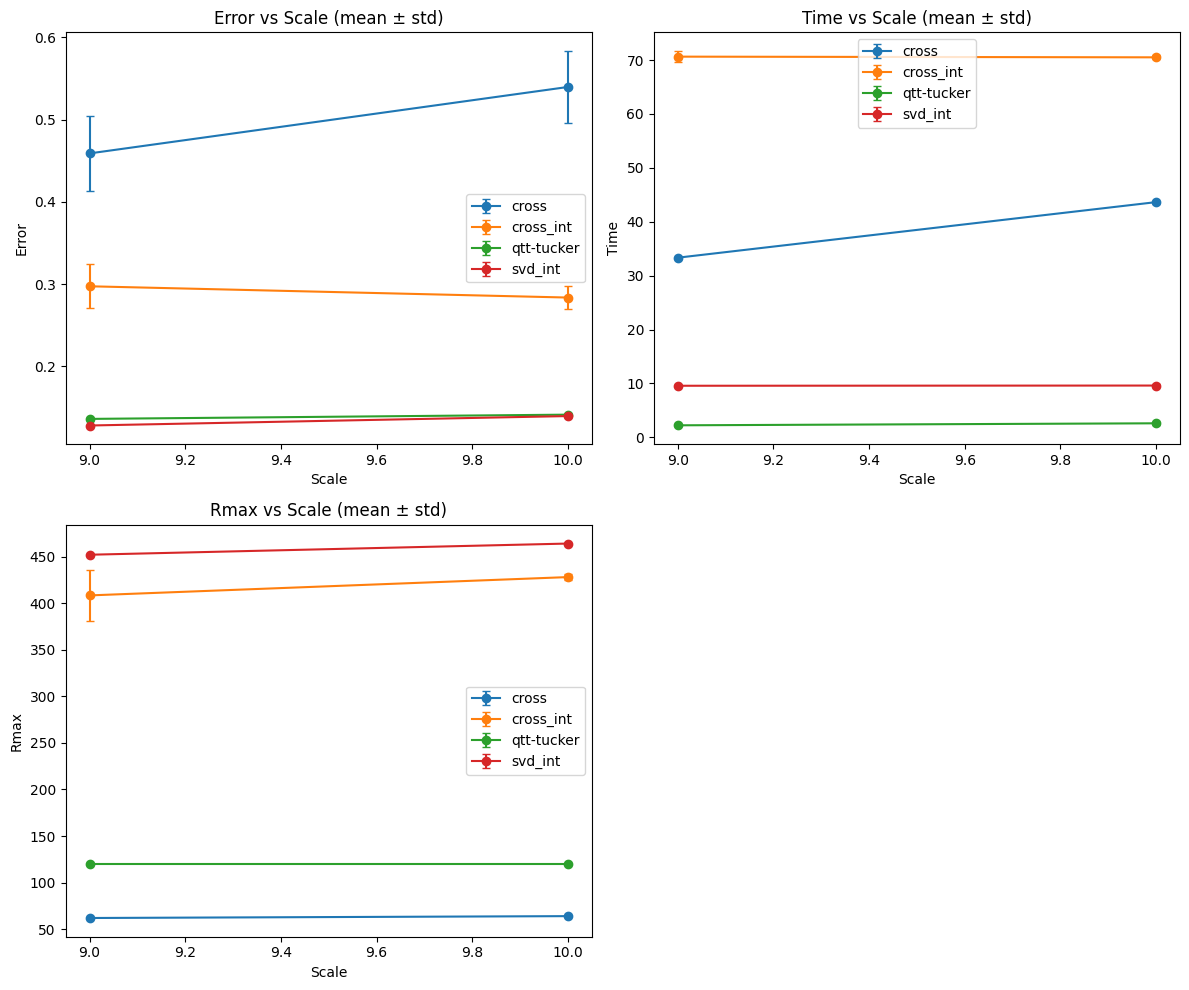

In [39]:
import matplotlib.pyplot as plt

# 1) Build combined DataFrame (same as you had)
df_c = pd.DataFrame({
    'method': m_comb,
    'scale':  s_comb,
    'error':  err_comb,
    'time':   t_comb,
    'rmax':   mr_comb,
    'erank':  comp_c,
})
df_all = pd.concat([df, df_c], ignore_index=True)

# 2) Average w.r.t. scale (per method) — and keep std for error bars
stats = (
    df_all
    .groupby(['method', 'scale'], as_index=False)
    .agg(
        error_mean=('error', 'mean'), error_std=('error', 'std'),
        time_mean =('time',  'mean'), time_std =('time',  'std'),
        rmax_mean =('rmax',  'mean'), rmax_std =('rmax',  'std'),
    )
)
# ensure deterministic ordering
stats = stats.sort_values(['method', 'scale'])

metrics = ['error', 'time', 'rmax']

# 3) Plot the averaged curves (with std as y-error)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    mean_col = f'{metric}_mean'
    std_col  = f'{metric}_std'
    for method, group in stats.groupby('method'):
        group = group.sort_values('scale')
        ax.errorbar(
            group['scale'], group[mean_col],
            yerr=group[std_col].fillna(0.0),
            fmt='-o', capsize=3, label=method
        )
    ax.set_xlabel('Scale')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()} vs Scale (mean ± std)')
    ax.legend()

# remove the unused 4th subplot (optional)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


# pre | time:      1.510 | evals: 0.00e+00 (+ 0.00e+00) | rank:  32.0 | 
#   1 | time:      6.248 | evals: 1.79e+04 (+ 2.69e+04) | rank:  29.3 | e: 1.0e+00 | 
#   2 | time:     12.421 | evals: 2.97e+04 (+ 7.70e+04) | rank:  34.0 | e: 4.2e-02 | 
#   3 | time:     21.556 | evals: 3.95e+04 (+ 1.49e+05) | rank:  38.7 | e: 1.5e-02 | stop: nswp | 


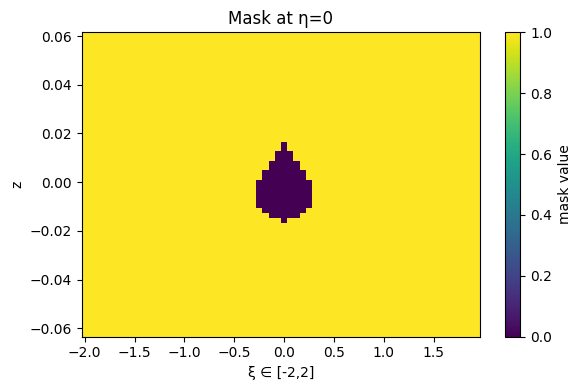

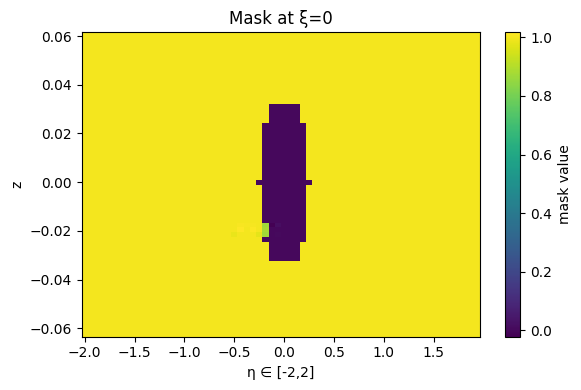

In [ ]:
p = 6
fd = p

eta_vals = np.linspace(-2,  2, 2**fd, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**fd, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**fd, endpoint=False)

n = [ 2,2,2]*p   # Shape of the tensor
m         = None  # Number of calls to target function
e         =  1e-8   # Desired accuracy
nswp      = 3   # Sweep number
r         = 30 + (p-p_coarse)*2      # TT-rank of the initial tensor
dr_min    = 2      # Cross parameter (minimum number of added rows)
dr_max    = 5      # Cross parameter (maximum number of added rows)

Y = ten.rand(n, r)
info_fine,cache = {}, {}
Y = ten.cross(f, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max, cache=cache,m_cache_scale=5,log=True,info=info_fine)
Yr = ten.truncate(Y, 1e-5) 
y_tt = tntt.TT( [tn.tensor(c,dtype=tn.float64) for c in Yr] ).full().reshape(N,N,N)

mf = z_order_to_normal_torch_3d(y_tt.flatten(),2**p,2**p,2**p).to(dtype=tn.float64)
#mf = mask_grid
#X, Y, Z = np.meshgrid(eta_vals, xi_ext,z_vals, indexing='ij')
#mf = wing_mask(X,Y,Z)

# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mf[i0,:,:], shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mf[:,j0,:], shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()



/tmp/ipykernel_4103271/1293029728.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rgba[:, 3] = (1 - mf).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0


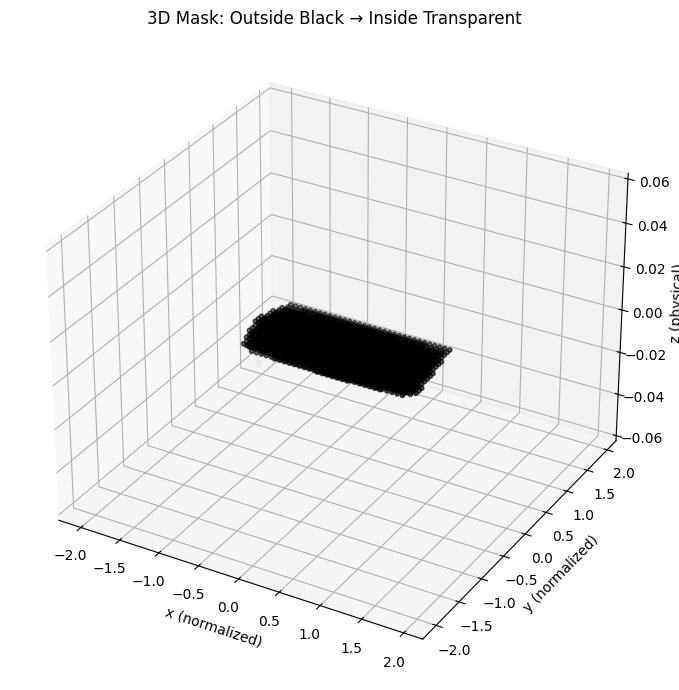

In [ ]:
x = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
y   = np.linspace(-2,  2, 2**p, endpoint=False)
z   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
X, Y, Z = np.meshgrid(x, y,z, indexing='ij')
rgba = np.zeros((mf.numpy().size, 4))
rgba[:, 3] = (1 - mf).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0
rgba = np.clip(rgba, 0, 1)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X.ravel(), Y.ravel(), Z.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

## Model 2

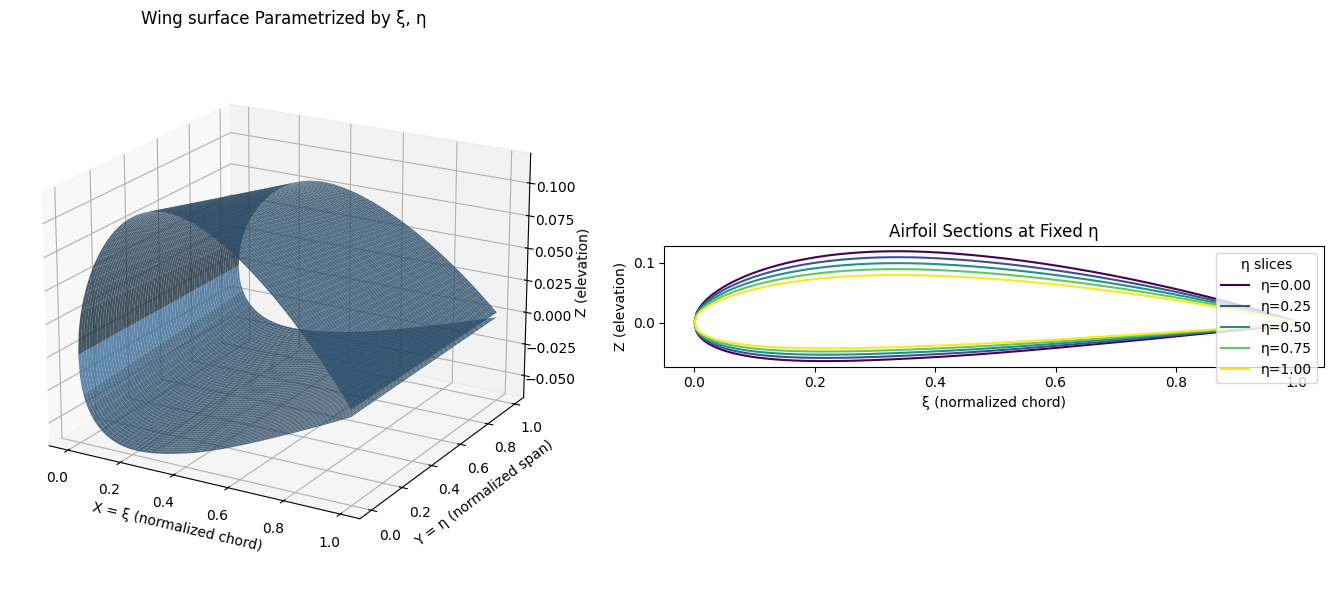

In [249]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ─── Wing parameters ───────────────────────────────────────────────────────────
b, c_r, c_t    = 10.0, 2.0, 1.0      # span, root & tip chord (unused in X,Y here)
Lambda_LE      = np.deg2rad(25)      # sweep (unused in X,Y here)
m, p_cam, t    = 0.02, 0.4, 0.12     # camber & thickness parameters

def chord(eta):
    return c_r * (1 - eta)/2 + c_t * (1 + eta)/2

def thickness_dist(xi):
    return 5*t * (
        0.2969*np.sqrt(xi)
        -0.1260*xi
        -0.3516*xi**2
        +0.2843*xi**3
        -0.1015*xi**4
    )

def camber_line(xi):
    yc = np.where(
        xi < p_cam,
        m/(p_cam**2)*(2*p_cam*xi - xi**2),
        m/((1-p_cam)**2)*((1-2*p_cam) + 2*p_cam*xi - xi**2)
    )
    dyc = np.where(
        xi < p_cam,
        2*m/(p_cam**2)*(p_cam - xi),
        2*m/((1-p_cam)**2)*(p_cam - xi)
    )
    return yc, dyc

# ─── Grid definition ──────────────────────────────────────────────────────────
p = 8
N = 2**p

# ξ, η ∈ [0,1), endpoint=False
xi_vals  = np.linspace(0.0, 1.0, N, endpoint=False)
eta_vals = np.linspace(0.0, 1.0, N, endpoint=False)

# 2D parametric grid: XI along X, ETA along Y
XI, ETA = np.meshgrid(xi_vals, eta_vals, indexing='ij')

# ─── Compute camber & thickness in 2D ────────────────────────────────────────
C      = chord(ETA)               # chord length (for scaling Z)
yc, _  = camber_line(XI)          # camber fraction
yt     = thickness_dist(XI)       # half-thickness fraction

# ─── Embed in 3D: X=ξ, Y=η, Z=surface elevation ─────────────────────────────
X       = XI
Y       = ETA

Z_upper = yc*C + yt*C
Z_lower = yc*C - yt*C

# ─── Plot the 3D wing surface ───────────────────────────────────────────────
fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z_upper, rstride=4, cstride=4, color='steelblue', alpha=0.8)
ax1.plot_surface(X, Y, Z_lower, rstride=4, cstride=4, color='steelblue', alpha=0.8)
ax1.set_xlabel('X = ξ (normalized chord)'); ax1.set_ylabel('Y = η (normalized span)')
ax1.set_zlabel('Z (elevation)')
ax1.set_title('Wing surface Parametrized by ξ, η')
ax1.view_init(elev=20, azim=-60)

# ─── Plot airfoil sections at constant η slices ──────────────────────────────
ax2 = fig.add_subplot(122)
eta_slices = [0.0, 0.25, 0.5, 0.75, 1.0]
colors     = plt.cm.viridis(np.linspace(0,1,len(eta_slices)))
for η, col in zip(eta_slices, colors):
    j = np.argmin(np.abs(eta_vals - η))
    ax2.plot(xi_vals, Z_upper[:, j], color=col)
    ax2.plot(xi_vals, Z_lower[:, j], color=col, label=f'η={η:.2f}')

ax2.set_aspect('equal')
ax2.set_xlabel('ξ (normalized chord)')
ax2.set_ylabel('Z (elevation)')
ax2.set_title('Airfoil Sections at Fixed η')
ax2.legend(title='η slices', loc='upper right')

plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_20288\1677919756.py:13: RuntimeWarning: invalid value encountered in sqrt
  return 5*t*(0.2969*np.sqrt(xi)


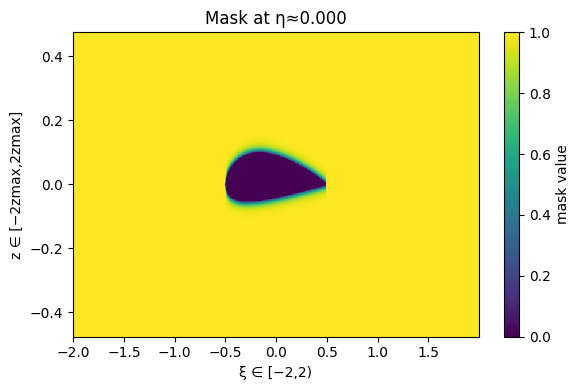

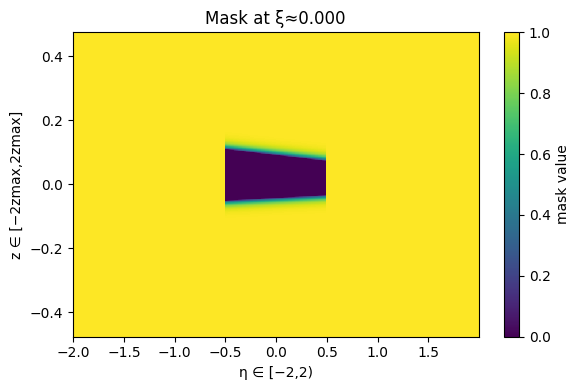

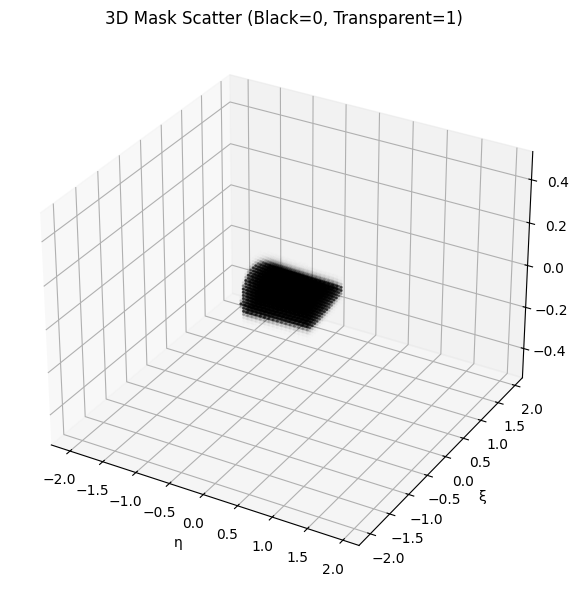

In [250]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Wing parameters ─────────────────────────────────────────────────────────
b, c_r, c_t = 10.0, 2.0, 1.0
Lambda_LE   = np.deg2rad(25)
m, p_cam, t = 0.02, 0.4, 0.12

def chord(eta):
    return c_r*(1 - eta)/2 + c_t*(1 + eta)/2

def thickness_dist(xi):
    return 5*t*(0.2969*np.sqrt(xi)
                -0.1260*xi
                -0.3516*xi**2
                +0.2843*xi**3
                -0.1015*xi**4)

def camber_line(xi):
    yc = np.where(xi < p_cam,
                  m/(p_cam**2)*(2*p_cam*xi - xi**2),
                  m/((1-p_cam)**2)*((1-2*p_cam) + 2*p_cam*xi - xi**2))
    return yc, None

# ─── 1) Compute z_max on the original [0,1)×[0,1) grid ─────────────────────
p = 9
N = 2**p

eta_core = np.linspace(0.0, 1.0, N, endpoint=False)
xi_core  = np.linspace(0.0, 1.0, N, endpoint=False)
ETA2, XI2 = np.meshgrid(eta_core, xi_core, indexing='ij')

C2     = chord(ETA2)
yc2, _ = camber_line(XI2)
yt2    = thickness_dist(XI2)

Zup2   = yc2*C2 + yt2*C2
Zlow2  = yc2*C2 - yt2*C2

zmax = np.max(np.abs([Zup2, Zlow2]))

# ─── 2) Build the extended grid η,ξ ∈ [−2,2), z ∈ [−2zmax,2zmax) ─────────────
eta_vals = np.linspace(-2.0, 2.0, N, endpoint=False)
xi_vals  = np.linspace(-2.0, 2.0, N, endpoint=False)
z_vals   = np.linspace(-4*zmax, 4*zmax, N, endpoint=False)

ETA3, XI3, ZG = np.meshgrid(eta_vals, xi_vals, z_vals, indexing='ij')

# ─── 3) Map extended coords back to “core” params and gate core region ───────
eta_mapped = ETA3 + 0.5   # now [−2,2)→[−1.5,2.5); core is [0,1)
xi_mapped  = XI3  + 0.5   # same
core_mask  = (
    (eta_mapped >= 0) & (eta_mapped < 1) &
    (xi_mapped  >= 0) & (xi_mapped  < 1)
)

# ─── 4) Compute wing surfaces at those mapped params ─────────────────────────
C3      = chord(eta_mapped)
yc3, _  = camber_line(xi_mapped)
yt3     = thickness_dist(xi_mapped)

Zup3    = yc3*C3 + yt3*C3
Zlow3   = yc3*C3 - yt3*C3

# ─── 5) Build the embedded mask ──────────────────────────────────────────────
mask = np.ones_like(ZG)

# inside wing → 0
inside = core_mask & (ZG >= Zlow3) & (ZG <= Zup3)
mask[inside] = 0.0

# above wing → 1 − exp(−100·Δz)
above = core_mask & (ZG > Zup3)
mask[above] = 1.0 - np.exp(-100.0 * (ZG[above] - Zup3[above]))

# below wing → 1 − exp(−100·Δz)
below = core_mask & (ZG < Zlow3)
mask[below] = 1.0 - np.exp(-100.0 * (Zlow3[below] - ZG[below]))

# ─── 6) Visualize central η‐slice and central ξ‐slice ────────────────────────
i_eta0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_vals, z_vals, mask[i_eta0,:,:].T, shading='auto')
plt.xlabel('ξ ∈ [−2,2)')
plt.ylabel('z ∈ [−2zmax,2zmax]')
plt.title(f'Mask at η≈{eta_vals[i_eta0]:.3f}')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

j_xi0 = np.argmin(np.abs(xi_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask[:,j_xi0,:].T, shading='auto')
plt.xlabel('η ∈ [−2,2)')
plt.ylabel('z ∈ [−2zmax,2zmax]')
plt.title(f'Mask at ξ≈{xi_vals[j_xi0]:.3f}')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ─── 7) 3D scatter of mask values ────────────────────────────────────────────
# Downsample for performance
step = 8
X_s = ETA3[::step, ::step, ::step].flatten()
Y_s = XI3[::step, ::step, ::step].flatten()
Z_s = ZG[::step, ::step, ::step].flatten()
m_s = mask[::step, ::step, ::step].flatten()

# RGBA: black when mask=0, transparent when mask=1
colors = np.zeros((m_s.size, 4))
colors[:, 3] = 1.0 - m_s  # alpha channel

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s, Y_s, Z_s, color=colors, s=2)
ax.set_xlabel('η')
ax.set_ylabel('ξ')
ax.set_zlabel('z')
ax.set_title('3D Mask Scatter (Black=0, Transparent=1)')
plt.tight_layout()
plt.show()


In [1]:


m = tn.tensor(mask, dtype=tn.float64)
#m = tn.permute(m, (0, 1, 2))  # ensure shape is (N, N, N)
twing = tntt.TT(zM3(m,p), [2,2,2]*p,eps=1e-3)

np.max(twing.R)

NameError: name 'tn' is not defined

In [53]:
tnmask = tn.tensor(mask,dtype=tn.float64)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R))


69


In [252]:

# assumes `mask` is a NumPy array
X_np = mask.astype(np.float64)              # keep high precision if you want
#X_np = np.transpose(X_np, axes=[0, 1, 2])   # your original transpose (no-op if already)
X = tn.from_numpy(X_np).to(dtype=tn.float64)

# ── HOSVD / Tucker via SVD on unfoldings ─────────────────────────────────────
def unfold_tn(X, mode):
    # move the chosen mode to the front, then flatten the rest
    return tn.movedim(X, mode, 0).reshape(X.shape[mode], -1)

def tucker_hosvd(X, ranks):
    """
    X: (I, J, K) torch tensor
    ranks: (r1, r2, r3)
    returns: core G (r1, r2, r3), factors (U1, U2, U3) with shapes (I,r1),(J,r2),(K,r3)
    """
    I, J, K = X.shape
    r1 = min(ranks[0], I)
    r2 = min(ranks[1], J)
    r3 = min(ranks[2], K)

    U = []
    for mode, r in enumerate((r1, r2, r3)):
        M = unfold_tn(X, mode)                               # (dim_mode, prod_other_dims)
        # SVD in torch
        U_mode, S_mode, Vh_mode = tn.linalg.svd(M, full_matrices=False)
        U.append(U_mode[:, :r].contiguous())                 # (dim_mode, r)

    U1, U2, U3 = U

    # Core: G = X ×1 U1^T ×2 U2^T ×3 U3^T  (einsum form)
    # X: ijk, U1^T: ai, U2^T: bj, U3^T: ck -> abc
    G = tn.einsum('ijk,ai,bj,ck->abc', X, U1.T, U2.T, U3.T)

    return G, (U1, U2, U3)

def tucker_reconstruct(G, factors):
    U1, U2, U3 = factors
    # X_hat = G ×1 U1 ×2 U2 ×3 U3  (einsum form)
    # G: abc, U1: ia, U2: jb, U3: kc -> ijk
    X_hat = tn.einsum('abc,ia,jb,kc->ijk', G, U1, U2, U3)
    return X_hat

# ── Run HOSVD/Tucker ─────────────────────────────────────────────────────────
rt = 100
G, U = tucker_hosvd(X, ranks=(rt, rt, rt))
X_hat = tucker_reconstruct(G, U)

# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - X_hat).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Core shape: {tuple(G.shape)}")
print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")


Core shape: (100, 100, 100)
Abs L2 error: 4.526687e-01
Rel error   : 3.924463e-05


In [260]:
comb_qtt = combqtt(G,U,eps=1e-10)
comb_c = tree_compress(comb_qtt,eps=1e-3)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
mrank_cqtt_c = comb_max_rank(comb_c)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

0.009241148829460144
0.0004811212420463562
129


In [262]:
print("\033[91m" + 
    str(np.max(twing.R)) + ", " + 
    str(int(erank(twing.R, twing.N))) + ", " + 
    str(tt_comp(twing)) +
    "\033[0m")

print("\033[92m" +
    str(np.max(ttmask.R)) + ", " +
    str(int(erank(ttmask.R, ttmask.N))) + ", " +
    str(tt_comp(ttmask)) +
    "\033[0m")

print("\033[93m" +
    str(mrank_cqtt_c) + ",   , " +
    str(comp_combc) + ", " +
    "\033[0m")

101, 37, 0.0005134344100952148
217, 124, 0.04075026512145996
88,   , 0.0004811212420463562, 


## Model 3

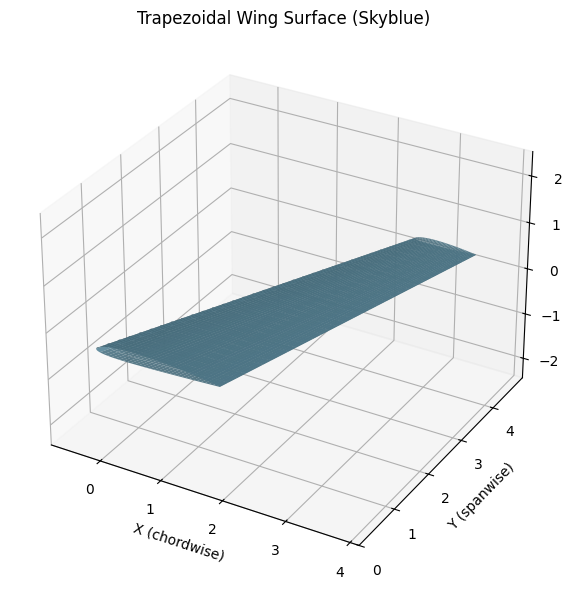

In [263]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    # chord, camber, thickness
    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(
        XI<p_cam,
        m/(p_cam**2)*(2*p_cam*XI - XI**2),
        m/((1-p_cam)**2)*((1-2*p_cam)+2*p_cam*XI - XI**2)
    )
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    # coordinates
    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    X = x_le + XI*C
    Y = 0.5 * b * ETA
    Zup = (yc+yt)*C
    Zlo = (yc-yt)*C

    return X, Y, Zup, Zlo

# plot
X, Y, Zup, Zlo = generate_trapezoidal_wing_surface()
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Zup,  rstride=4, cstride=4, color='#87CEEB', edgecolor='none', alpha=0.9)
ax.plot_surface(X, Y, Zlo,  rstride=4, cstride=4, color='#87CEEB', edgecolor='none', alpha=0.9)

# equal aspect
max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Zup.max()-Zlo.min()]).max()/2
mid_x = (X.max()+X.min())/2
mid_y = (Y.max()+Y.min())/2
mid_z = (Zup.max()+Zlo.min())/2
ax.set_xlim(mid_x-max_range, mid_x+max_range)
ax.set_ylim(mid_y-max_range, mid_y+max_range)
ax.set_zlim(mid_z-max_range, mid_z+max_range)

ax.set_xlabel('X (chordwise)')
ax.set_ylabel('Y (spanwise)')
ax.set_zlabel('Z (thickness)')
ax.set_title('Trapezoidal Wing Surface (Skyblue)')
plt.tight_layout()
plt.show()


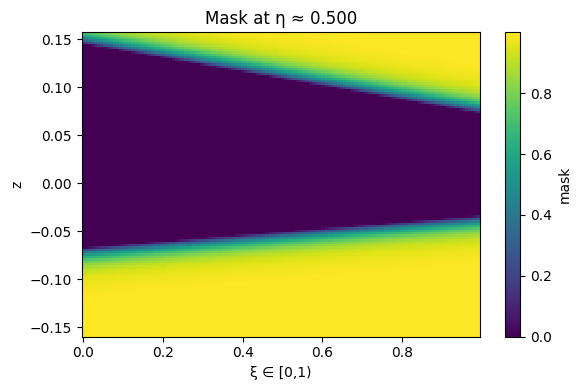

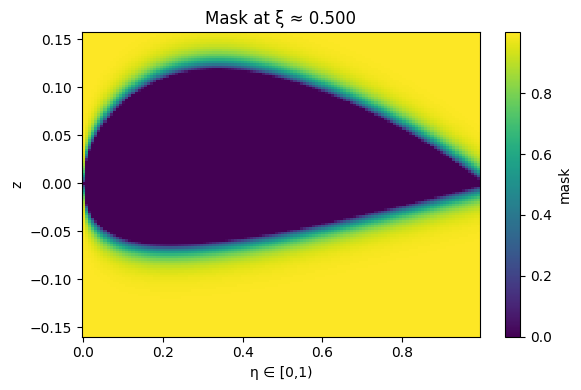

In [264]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Wing surface function (from last version) ──────────────────────────────
def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    # chord, camber, thickness
    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(
        XI < p_cam,
        m/(p_cam**2)*(2*p_cam*XI - XI**2),
        m/((1-p_cam)**2)*((1-2*p_cam)+2*p_cam*XI - XI**2)
    )
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    # coordinates with sweep
    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    X = x_le + XI*C
    Y = 0.5 * b * ETA
    Zup = (yc + yt)*C
    Zlo = (yc - yt)*C

    return eta, xi, X, Y, Zup, Zlo

# ─── 1) Generate wing surface ───────────────────────────────────────────────
eta, xi, Xw, Yw, Zup, Zlo = generate_trapezoidal_wing_surface()
N = Xw.shape[0]  # grid size

# ─── 2) Define z-grid based on wing thickness ───────────────────────────────
zlim = np.max(np.abs([Zup, Zlo]))
z_vals = np.linspace(-zlim, zlim, N, endpoint=False)

# ─── 3) Build 3D grid (η, ξ, z) ──────────────────────────────────────────────
ETA3, XI3, ZG = np.meshgrid(eta, xi, z_vals, indexing='ij')

# ─── 4) Broadcast wing surfaces to 3D ───────────────────────────────────────
Zup3d  = Zup[:, :, None]  # shape (N, N, 1)
Zlow3d = Zlo[:, :, None]

# ─── 5) Initialize mask = 1 everywhere ─────────────────────────────────────
mask = np.ones_like(ZG)

# 5a) Inside wing: z between lower and upper surfaces → mask = 0
inside = (ZG >= Zlow3d) & (ZG <= Zup3d)
mask[inside] = 0.0

# 5b) Above wing: mask = 1 - exp(-100 * (z - Zup))
zd_above = ZG - Zup3d
above = zd_above > 0
mask[above] = 1.0 - np.exp(-100.0 * zd_above[above])

# 5c) Below wing: mask = 1 - exp(-100 * (Zlow - z))
zd_below = Zlow3d - ZG
below = zd_below > 0
mask[below] = 1.0 - np.exp(-100.0 * zd_below[below])

# ─── 6) Visualize a central spanwise (η) slice ──────────────────────────────
i_mid = N//2
plt.figure(figsize=(6,4))
plt.pcolormesh(xi, z_vals, mask[i_mid,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [0,1)')
plt.ylabel('z')
plt.title(f'Mask at η ≈ {eta[i_mid]:.3f}')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()

# ─── 7) Visualize a central chordwise (ξ) slice ─────────────────────────────
j_mid = N//2
plt.figure(figsize=(6,4))
plt.pcolormesh(eta, z_vals, mask[:,j_mid,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [0,1)')
plt.ylabel('z')
plt.title(f'Mask at ξ ≈ {xi[j_mid]:.3f}')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_20288\3135391486.py:70: RuntimeWarning: invalid value encountered in sqrt
  yt_g = 5*t*(0.2969*np.sqrt(xi_g)


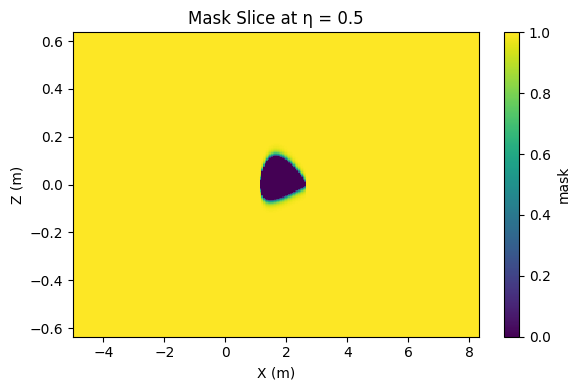

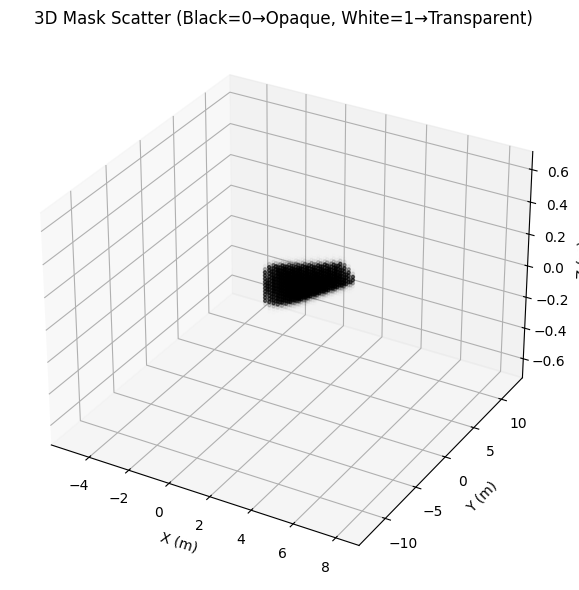

In [265]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ─── 1) Core wing surface function ───────────────────────────────────────────
def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(XI<p_cam,
                  m/(p_cam**2)*(2*p_cam*XI - XI**2),
                  m/((1-p_cam)**2)*(1-2*p_cam + 2*p_cam*XI - XI**2))
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    Xw  = x_le + XI * C
    Yw  = 0.5 * b * ETA
    Zup = (yc + yt) * C
    Zlo = (yc - yt) * C

    return Xw, Yw, Zup, Zlo, b

# Generate wing surface
Xw, Yw, Zup, Zlo, b = generate_trapezoidal_wing_surface(N=128)

# ─── 2) Build mask in extended domain (2× larger) ───────────────────────────
# Wing bounding box
xmin, xmax = Xw.min(), Xw.max()
ymin, ymax = Yw.min(), Yw.max()
zlim = np.max(np.abs([Zup, Zlo]))

# Extended domain twice as large around center
mid_x = 0.5*(xmin + xmax)
mid_y = 0.5*(ymin + ymax)
half_dx = (xmax - xmin)
half_dy = (ymax - ymin)

N_dom = 2**8
X_vals = np.linspace(mid_x - 2*half_dx, mid_x + 2*half_dx, N_dom)
Y_vals = np.linspace(mid_y - 3*half_dy, mid_y + 2*half_dy, N_dom)
Z_vals = np.linspace(-4*zlim, 4*zlim, N_dom)

Xg, Yg, Zg = np.meshgrid(X_vals, Y_vals, Z_vals, indexing='ij')

# Map to (eta, xi)
eta_g = Yg / (0.5*b)
x_le_g = 0.5 * b * eta_g * np.tan(np.deg2rad(25))
C_g = (2.0*(1-eta_g) + 1.0*eta_g)  # chord
xi_g = (Xg - x_le_g) / C_g

# Core region
core = (eta_g>=0)&(eta_g<1)&(xi_g>=0)&(xi_g<1)

# Surfaces
m, p_cam, t = 0.02, 0.4, 0.12
yc_g = np.where(xi_g<p_cam,
                m/(p_cam**2)*(2*p_cam*xi_g - xi_g**2),
                m/((1-p_cam)**2)*(1-2*p_cam + 2*p_cam*xi_g - xi_g**2))
yt_g = 5*t*(0.2969*np.sqrt(xi_g)
           -0.1260*xi_g
           -0.3516*xi_g**2
           +0.2843*xi_g**3
           -0.1015*xi_g**4)
Zup_g  = (yc_g + yt_g) * C_g
Zlo_g  = (yc_g - yt_g) * C_g

# Build mask
mask = np.ones_like(Zg)
inside = core & (Zg >= Zlo_g) & (Zg <= Zup_g)
mask[inside] = 0.0
above = core & (Zg > Zup_g)
mask[above] = 1.0 - np.exp(-100*(Zg[above] - Zup_g[above]))
below = core & (Zg < Zlo_g)
mask[below] = 1.0 - np.exp(-100*(Zlo_g[below] - Zg[below]))

# ─── 3) Chordwise eta=0.5 slice with physical X axis ────────────────────────
eta_slice = 0.5
y_slice = 0.5 * b * eta_slice
j_y = np.argmin(np.abs(Y_vals - y_slice))
X_line = X_vals
mask_eta_slice = mask[:, j_y, :]

plt.figure(figsize=(6,4))
plt.pcolormesh(X_line, Z_vals, mask_eta_slice.T, shading='auto', cmap='viridis')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.title('Mask Slice at η = 0.5')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()

# ─── 4) 3D scatter of mask values ────────────────────────────────────────────
# Downsample for plotting
step = 4
X_s = Xg[::step,::step,::step].flatten()
Y_s = Yg[::step,::step,::step].flatten()
Z_s = Zg[::step,::step,::step].flatten()
m_s = mask[::step,::step,::step].flatten()

# RGBA colors: black for mask=0, transparent for mask=1
colors = np.zeros((m_s.size, 4))
colors[:, 3] = 1.0 - m_s  # alpha channel

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s, Y_s, Z_s, color=colors, s=5)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D Mask Scatter (Black=0→Opaque, White=1→Transparent)')
plt.tight_layout()
plt.show()


In [266]:
p=8
no = tntt.TT(mask, [2,2,2]*8, eps=1e-3)
np.max(no.R)

119

In [267]:
zo = tntt.TT(zM3(tn.tensor(mask,dtype=tn.float64),p), [2,2,2]*8, eps=1e-3)
np.max(zo.R)

120

In [268]:
tnmask = tn.tensor(mask,dtype=tn.float64).permute((1, 0, 2))  # ensure shape is (N, N, N)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R))


201


In [272]:

# assumes `mask` is a NumPy array
X_np = mask.astype(np.float64)              # keep high precision if you want
#X_np = np.transpose(X_np, axes=[0, 1, 2])   # your original transpose (no-op if already)
X = tn.from_numpy(X_np).to(dtype=tn.float64)

# ── HOSVD / Tucker via SVD on unfoldings ─────────────────────────────────────
def unfold_tn(X, mode):
    # move the chosen mode to the front, then flatten the rest
    return tn.movedim(X, mode, 0).reshape(X.shape[mode], -1)

def tucker_hosvd(X, ranks):
    """
    X: (I, J, K) torch tensor
    ranks: (r1, r2, r3)
    returns: core G (r1, r2, r3), factors (U1, U2, U3) with shapes (I,r1),(J,r2),(K,r3)
    """
    I, J, K = X.shape
    r1 = min(ranks[0], I)
    r2 = min(ranks[1], J)
    r3 = min(ranks[2], K)

    U = []
    for mode, r in enumerate((r1, r2, r3)):
        M = unfold_tn(X, mode)                               # (dim_mode, prod_other_dims)
        # SVD in torch
        U_mode, S_mode, Vh_mode = tn.linalg.svd(M, full_matrices=False)
        U.append(U_mode[:, :r].contiguous())                 # (dim_mode, r)

    U1, U2, U3 = U

    # Core: G = X ×1 U1^T ×2 U2^T ×3 U3^T  (einsum form)
    # X: ijk, U1^T: ai, U2^T: bj, U3^T: ck -> abc
    G = tn.einsum('ijk,ai,bj,ck->abc', X, U1.T, U2.T, U3.T)

    return G, (U1, U2, U3)

def tucker_reconstruct(G, factors):
    U1, U2, U3 = factors
    # X_hat = G ×1 U1 ×2 U2 ×3 U3  (einsum form)
    # G: abc, U1: ia, U2: jb, U3: kc -> ijk
    X_hat = tn.einsum('abc,ia,jb,kc->ijk', G, U1, U2, U3)
    return X_hat

# ── Run HOSVD/Tucker ─────────────────────────────────────────────────────────
rt = 100
G, U = tucker_hosvd(X, ranks=(rt, rt, rt))
X_hat = tucker_reconstruct(G, U)

# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - X_hat).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Core shape: {tuple(G.shape)}")
print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")


Core shape: (100, 100, 100)
Abs L2 error: 1.369542e-11
Rel error   : 3.348294e-15


In [273]:
comb_qtt = combqtt(G,U,eps=1e-10)
comb_c = tree_compress(comb_qtt,eps=1e-3)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
mrank_cqtt_c = comb_max_rank(comb_c)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

0.027173757553100586
0.00713270902633667
128


In [276]:
cr = combqtt_full(comb_c)
err_abs = tn.linalg.norm((X - cr).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")

Abs L2 error: 5.131651e+00
Rel error   : 1.254600e-03


In [275]:
print("\033[91m" + 
    str(np.max(zo.R)) + ", " + str(int(erank(zo.R, zo.N))) + ", " + str(tt_comp(zo)) +
    "\033[0m")

print("\033[92m" + 
    str(np.max(ttmask.R)) + ", " + str(int(erank(ttmask.R, ttmask.N))) + ", " + str(tt_comp(ttmask)) +
    "\033[0m")

print("\033[94m" + 
    str(comb_max_rank(comb_c)) + ",  , "+str(comb_comp(comb_c))  + 
    "\033[0m")

120, 47, 0.005820035934448242
201, 99, 0.026072263717651367
59,  , 0.00713270902633667


## Model 4

[check] TE_x - LE_x at mid-span = 4.0478 (>0 means TE toward +X)


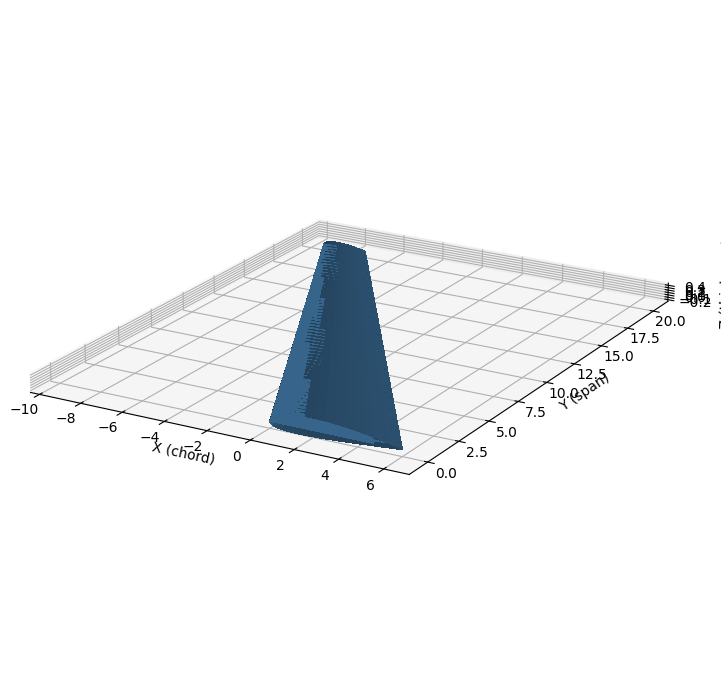

[shapes] chi_grid: (120, 60, 120)  mask01: (120, 60, 120)


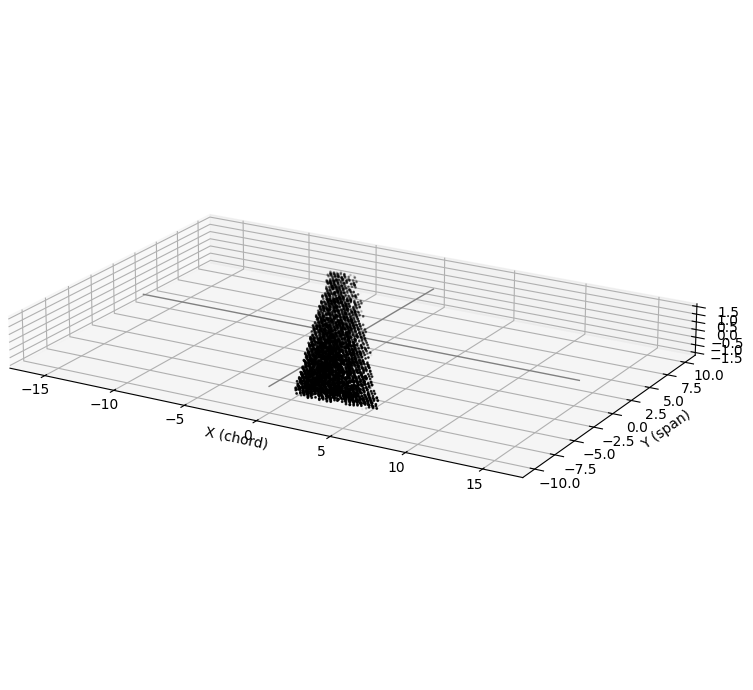

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# =========================
# 1) Airfoil + pure wing (with explicit chord & sweep signs)
# =========================
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    assert n % 2 == 0 and n >= 6
    n2  = n // 2
    beta = np.linspace(0.0, np.pi, n2 + 1)
    x  = 0.5 * (1.0 - np.cos(beta))            # [0,1]
    x_ = np.clip(x, 0.0, 1.0)

    yt = 5*t*(0.2969*np.sqrt(x_) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dy = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dy)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]            # LE->TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]      # TE->LE (drop duplicates)
    lower_z = zl[1:-1][::-1]
    return np.concatenate([upper_x, lower_x]), np.concatenate([upper_z, lower_z])

def build_wing(
    half_span=20.0, c_root=6.0, taper=0.36,
    sweep_LE_deg=25.0, dihedral_deg=0.0,
    n_chord=120, n_wing=60,
    chord_forward=True, backward_sweep=True,
):
    # section
    x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)

    c_tip = taper * c_root
    c_sign = +1.0 if chord_forward else -1.0          # LE -> TE along +X or -X
    sw_sign = -1.0 if backward_sweep else +1.0        # LE shift with span

    sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span * sw_sign
    dihedral  = np.tan(np.deg2rad(dihedral_deg))

    X = np.zeros((n_wing, n_chord))
    Y = np.zeros((n_wing, n_chord))
    Z = np.zeros((n_wing, n_chord))

    for j in range(n_wing):
        s = j / (n_wing - 1.0)              # 0..1
        c = c_root + (c_tip - c_root) * s
        x_le = sweep_off * s                # note: if backward_sweep=True, this is negative
        y    = half_span * s
        z0   = dihedral * y

        X[j, :] = x_le + c_sign * c * x_sec
        Y[j, :] = y
        Z[j, :] = z0   + c * z_sec

    return X, Y, Z

# Choose the conventions you want here:
X, Y, Z = build_wing(
    chord_forward=True,   # LE->TE in +X (typical)
    backward_sweep=True   # airliner-style backward sweep
)

# Direction sanity check (mid-span)
mid = X.shape[0] // 2
LE_x = X[mid, :].min()
TE_x = X[mid, :].max()
print(f"[check] TE_x - LE_x at mid-span = {TE_x - LE_x:.4f} (>0 means TE toward +X)")

# =========================
# 2) Plot parametric wing (with axes + arrow)
# =========================
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=3, color='steelblue',
                edgecolor='none', antialiased=False)
# arrow at mid-span showing chord direction
y0 = Y[mid, 0]
z0 = np.mean(Z[mid, :])
ax.quiver(LE_x, y0, z0, (TE_x-LE_x)*0.15, 0, 0, color='gray',
          linewidth=2, arrow_length_ratio=0.15)

ax.view_init(elev=20, azim=-60)
ax.set_xlabel('X (chord)'); ax.set_ylabel('Y (span)'); ax.set_zlabel('Z (thickness)')
ax.set_box_aspect([float(np.ptp(X)), float(np.ptp(Y)), float(np.ptp(Z))])
plt.tight_layout(); plt.show()

# =========================
# 3) Center wing; define 4x box in X,Z (Y unchanged)
# =========================
x_mid = 0.5*(X.min()+X.max())
y_mid = 0.5*(Y.min()+Y.max())
z_mid = 0.5*(Z.min()+Z.max())
Xc, Yc, Zc = X-x_mid, Y-y_mid, Z-z_mid

X_extent = float(Xc.max() - Xc.min())
Y_extent = float(Yc.max() - Yc.min())      # unchanged
Z_extent = float(Zc.max() - Zc.min())

gx_min, gx_max = -X_extent,  X_extent
gy_min, gy_max =  Yc.min(),      Yc.max()
gz_min, gz_max = -2.0*Z_extent,  2.0*Z_extent

dz_max = max(Z_extent, 1e-9)               # normalization for decay

# =========================
# 4) Mesh + ray helpers (lightweight)
# =========================
def triangulate_swept_cyclic(Xs, Ys, Zs):
    rows, cols = Xs.shape
    V = np.column_stack([Xs.ravel(), Ys.ravel(), Zs.ravel()])
    faces = []
    for i in range(rows - 1):
        b0 = i*cols; b1 = (i+1)*cols
        for j in range(cols):
            jn = (j+1) % cols
            a = b0+j; b = b0+jn; c = b1+j; d = b1+jn
            faces.append([a,c,b]); faces.append([b,c,d])
    loop0 = np.arange(0, cols)
    cent0 = V[loop0].mean(axis=0); idx0 = V.shape[0]
    V = np.vstack([V, cent0])
    for j in range(cols): faces.append([loop0[j], loop0[(j+1)%cols], idx0])
    loop1 = np.arange((rows-1)*cols, rows*cols)
    cent1 = V[loop1].mean(axis=0); idx1 = V.shape[0]
    V = np.vstack([V, cent1])
    for j in range(cols): faces.append([loop1[(j+1)%cols], loop1[j], idx1])
    return trimesh.Trimesh(vertices=V, faces=np.asarray(faces, np.int64), process=True)

wing_mesh = triangulate_swept_cyclic(Xc, Yc, Zc)

try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    RAY = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    RAY = "python"
wing_ray = RayMeshIntersector(wing_mesh)

def contains_chunked(intersector, pts, chunk=200_000):
    pts = np.asarray(pts, float)
    out = np.empty(pts.shape[0], dtype=bool)
    for i in range(0, pts.shape[0], chunk):
        sl = slice(i, min(i+chunk, pts.shape[0]))
        out[sl] = intersector.contains_points(pts[sl])
    return out

def dz_along_z_light(intersector, pts, chunk=150_000):
    """
    Distance along +/-Z using rays; if both miss, fallback to AABB distance in Z.
    """
    pts = np.asarray(pts, float)
    out = np.empty(pts.shape[0], float)
    mn, mx = intersector.mesh.bounds
    dir_p = np.array([0.0, 0.0,  1.0])
    dir_n = np.array([0.0, 0.0, -1.0])
    for i in range(0, pts.shape[0], chunk):
        sl = slice(i, min(i+chunk, pts.shape[0]))
        P = pts[sl]
        loc_p, ind_p, _ = intersector.intersects_location(P, np.repeat(dir_p[None,:], P.shape[0], axis=0), multiple_hits=False)
        loc_n, ind_n, _ = intersector.intersects_location(P, np.repeat(dir_n[None,:], P.shape[0], axis=0), multiple_hits=False)
        d = np.full(P.shape[0], np.inf, float)
        if ind_p.size: d[ind_p] = np.minimum(d[ind_p], np.abs(loc_p[:,2] - P[ind_p,2]))
        if ind_n.size: d[ind_n] = np.minimum(d[ind_n], np.abs(loc_n[:,2] - P[ind_n,2]))
        miss = ~np.isfinite(d)
        if np.any(miss):
            zmin, zmax = mn[2], mx[2]
            z = P[miss, 2]
            dz = np.where(z < zmin, zmin - z,
                 np.where(z > zmax, z - zmax, np.minimum(z - zmin, zmax - z)))
            d[miss] = np.abs(dz)
        out[sl] = d
    return out

# =========================
# 5) Grid & SHARP decaying mask (k=1000) + 3D ARRAY OUTPUT
# =========================
# Grid in box: X,Z expanded 4×; Y unchanged
nx, ny, nz = 120, 60, 120   # denser in X,Z
gx = np.linspace(gx_min, gx_max, nx)
gy = np.linspace(gy_min, gy_max, ny)
gz = np.linspace(gz_min, gz_max, nz)
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing='ij')  # ij -> (x,y,z) order

# Flatten for queries
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# Prefilter near AABB to save time
pad_xz = 0.1 * max(X_extent, Z_extent)
mn, mx = wing_mesh.bounds
mn = mn + np.array([-pad_xz, 0.0, -pad_xz])
mx = mx + np.array([ pad_xz, 0.0,  pad_xz])
near = (grid_pts[:,0] >= mn[0]) & (grid_pts[:,0] <= mx[0]) & \
       (grid_pts[:,1] >= mn[1]) & (grid_pts[:,1] <= mx[1]) & \
       (grid_pts[:,2] >= mn[2]) & (grid_pts[:,2] <= mx[2])

# Initialize to 1 (outside)
val_flat = np.ones(grid_pts.shape[0], float)
k_sharp = 1000.0

if np.any(near):
    P = grid_pts[near]
    inside = contains_chunked(wing_ray, P)
    val_n = np.ones(P.shape[0], float)
    val_n[inside] = 0.0
    if np.any(~inside):
        dz = dz_along_z_light(wing_ray, P[~inside])
        val_n[~inside] = 1.0 - np.exp(-k_sharp * dz / dz_max)
    val_flat[near] = val_n

# >>> This is your 3D mask array in the embedded space:
chi_grid = val_flat.reshape(nx, ny, nz)     # 0 inside, sharp-decayed outside

# Optional hard 0/1 mask:
mask01 = (chi_grid > 0).astype(np.uint8)

print(f"[shapes] chi_grid: {chi_grid.shape}  mask01: {mask01.shape}")

# =========================
# 6) Quick visualization (scatter with axes)
# =========================
# Build per-point alpha from chi_grid for a sample slice of points (to keep light)
alpha = 1.0 - np.clip(chi_grid.ravel(), 0.0, 1.0)
colors = np.column_stack([np.zeros_like(alpha),
                          np.zeros_like(alpha),
                          np.zeros_like(alpha),
                          alpha])

# Subsample for speed if needed
max_points = 250_000
N = grid_pts.shape[0]
if N > max_points:
    idx = np.random.choice(N, max_points, replace=False)
    Pshow, Cshow = grid_pts[idx], colors[idx]
else:
    Pshow, Cshow = grid_pts, colors

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Pshow[:,0], Pshow[:,1], Pshow[:,2], s=1, c=Cshow, marker='o')

# axes
axis_col = (0.5, 0.5, 0.5)
ax.plot([gx_min, gx_max], [0,0], [0,0], lw=1, color=axis_col)
ax.plot([0,0], [gy_min, gy_max], [0,0], lw=1, color=axis_col)
ax.plot([0,0], [0,0], [gz_min, gz_max], lw=1, color=axis_col)

ax.set_xlabel('X (chord)')
ax.set_ylabel('Y (span)')
ax.set_zlabel('Z (thickness)')
ax.set_box_aspect([float(np.ptp(Pshow[:,0])),
                   float(np.ptp(Pshow[:,1])),
                   float(np.ptp(Pshow[:,2]))])
ax.view_init(elev=20, azim=-60)
plt.tight_layout(); plt.show()


In [49]:
2**21

2097152

# Wing + winglet

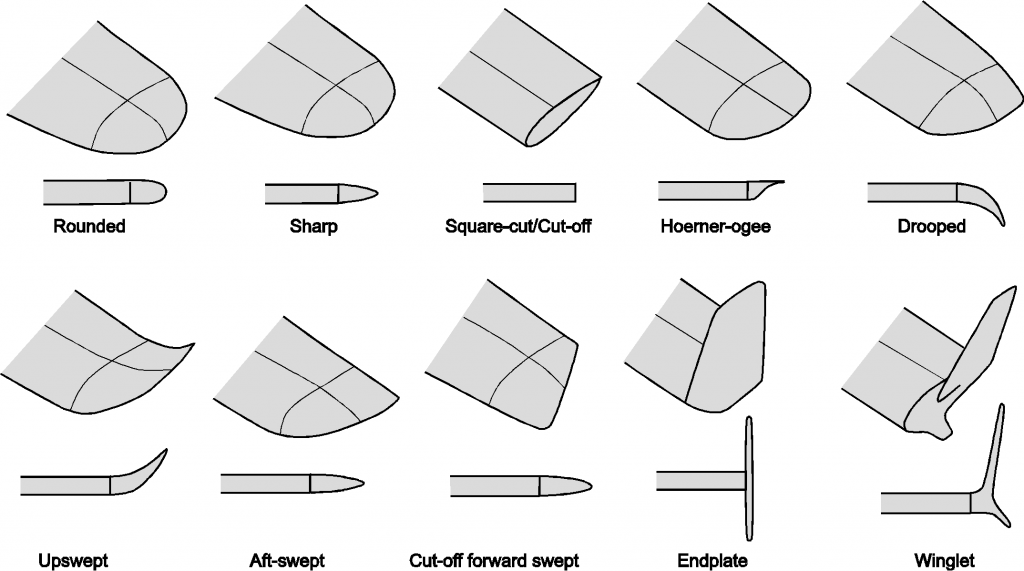

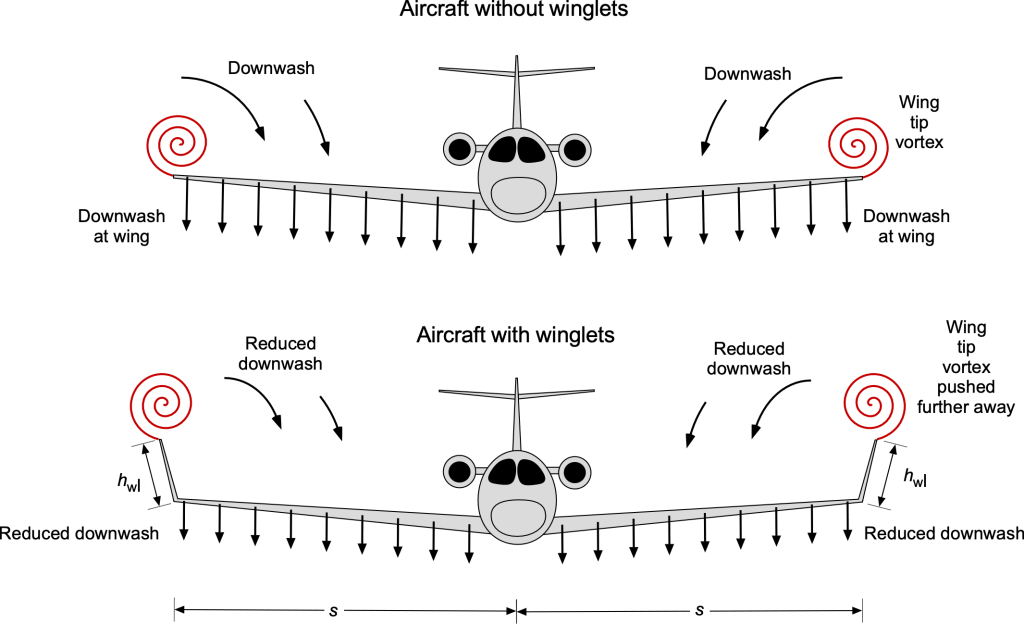

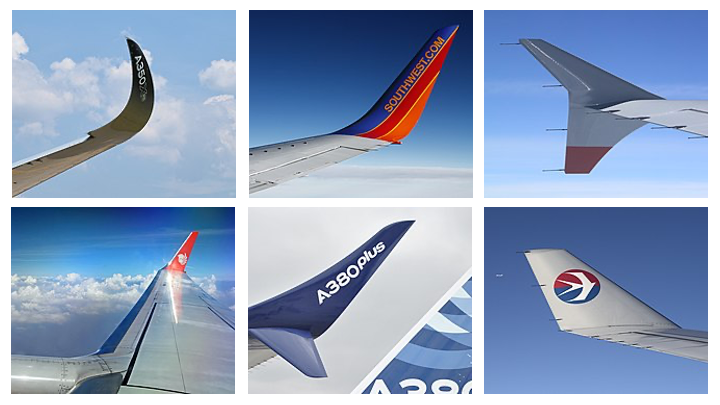

In [361]:
%matplotlib ipympl

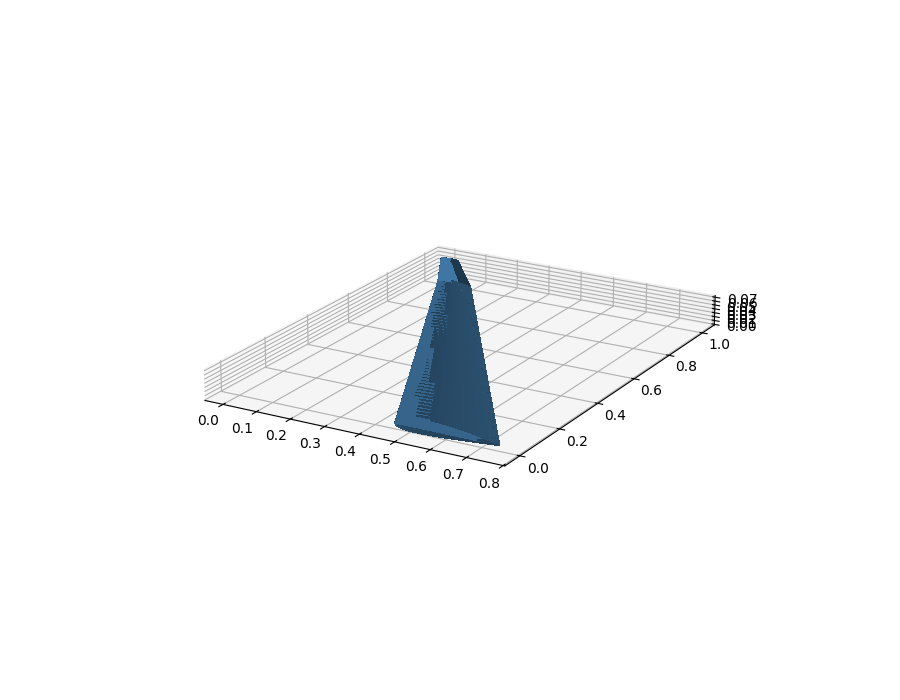

In [362]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*0.12*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
                 + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]               # LE -> TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # TE -> LE (drop TE & LE)
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):  # smooth rotation blend
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# More realistic proportions
# -----------------------------
half_span      = 20.0                 # arbitrary units (we'll normalize later)
taper_ratio    = 0.36                 # tip/root chord ratio (typical 0.3–0.45)
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0                 # 20–35° typical
dihedral_deg   = 0.0                  # keep 0 for clarity in this view

# Winglet as fraction of half-span (≈ 4–8%)
winglet_h_frac = 0.06                 # 6% of half-span
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span     # small outward cant (~2% span)
wl_alpha_max   = 65.0                 # degrees rotation toward vertical
wl_top_chord   = 0.5 * c_tip          # slimmer chord at winglet tip

# Discretization (kept modest for speed)
n_chord = 120   # even
n_wing  = 50
n_wl    = 30

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)              # 0..1
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Uniformly normalize to unit cube [0,1]^3 (no distortion)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0  # uniform scale
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale  # now the whole surface fits inside [0,1]^3

# -----------------------------
# Plot (parametric surface)
# -----------------------------
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xn, Yn, Zn, rstride=1, cstride=3,
                color='steelblue', edgecolor='none', antialiased=False)

ax.view_init(elev=20, azim=-60)

# Aspect based on normalized extents
x_extent = float(np.ptp(Xn)); y_extent = float(np.ptp(Yn)); z_extent = float(np.ptp(Zn))
x_extent = max(x_extent, 1e-6); y_extent = max(y_extent, 1e-6); z_extent = max(z_extent, 1e-6)
ax.set_box_aspect([x_extent, y_extent, z_extent])



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import time
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    # Closed loop: upper LE->TE, then lower TE->LE, drop duplicates
    upper_x = xu[::-1]               # length n_half+1
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # length n_half-1
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Realistic-ish proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet ≈ 6% half-span
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip


p = 6
n_p = 2**p
# Discretization (moderate for speed)
n_chord = n_p   # even
n_wing  = n_p
n_wl    = n_p

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3, then center to [-0.5,0.5]^3
# (kept identical to your example)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale

# Centered wing coords in [-0.5, 0.5]^3
Xc = Xn - 0.5
Yc = Yn - 0.5
Zc = Zn - 0.5

# -----------------------------
# Build watertight mesh (for inside test)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []

    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])

    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    idx_cent0 = V.shape[0]
    V = np.vstack([V, centroid0])
    for j in range(cols):
        a = loop0[j]
        b = loop0[(j + 1) % cols]
        c = idx_cent0
        faces.append([a, b, c])

    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    idx_cent1 = V.shape[0]
    V = np.vstack([V, centroid1])
    for j in range(cols):
        a = loop1[j]
        b = loop1[(j + 1) % cols]
        c = idx_cent1
        faces.append([b, a, c])

    F = np.asarray(faces, dtype=np.int64)
    return trimesh.Trimesh(vertices=V, faces=F, process=True)

mesh = triangulate_swept_cyclic(Xc, Yc, Zc)

# -----------------------------
# Fast contains: Embree if available + chunking
# -----------------------------
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"

ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

def contains_points_fast(pts, chunk=250_000):
    pts = np.asarray(pts, dtype=float)
    inside = np.empty(pts.shape[0], dtype=bool)
    n = pts.shape[0]
    for i in range(0, n, chunk):
        sl = slice(i, min(i+chunk, n))
        inside[sl] = ray.contains_points(pts[sl])
    return inside

# -----------------------------
# Big box: 4× unit cube side → [-2, 2]^3 (as in your example)
# Grid and timings
# -----------------------------
p = 9                           # your example; 512^3 points → huge! adjust if needed
nx, ny, nz = 2**p, 2**p, 2**p
gx = np.linspace(-2.0, 2.0, nx)
gy = np.linspace(-2.0, 2.0, ny)
gz = np.linspace(-2.0, 2.0, nz)

t_grid0 = time.perf_counter()
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)
t_grid1 = time.perf_counter()
print(f"[Grid] Built grid of {grid_pts.shape[0]:,} points in {t_grid1 - t_grid0:.2f}s")

# -----------------------------
# TIMING A) Mask creation
# -----------------------------
t0 = time.perf_counter()
inside_bool = contains_points_fast(grid_pts, chunk=250_000)
mask_flat = (~inside_bool).astype(np.uint8)  # 0 inside, 1 outside
t1 = time.perf_counter()
print(f"[Mask] Creation took {t1 - t0:.2f}s for {grid_pts.shape[0]:,} points")

# -----------------------------
# TIMING B) Scatter plotting (inside points only)
# -----------------------------
inside_pts = grid_pts[mask_flat == 0]

# Optional subsample for speed/clarity
max_points = 300_000
if inside_pts.shape[0] > max_points:
    idx = np.random.choice(inside_pts.shape[0], max_points, replace=False)
    inside_pts = inside_pts[idx]

t2 = time.perf_counter()
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
           c="k", s=1, alpha=1.0, marker="o")

# Equal-ish aspect
ext = np.array([np.ptp(inside_pts[:,0]),
                np.ptp(inside_pts[:,1]),
                np.ptp(inside_pts[:,2])], dtype=float)
ext[ext == 0] = 1.0
ax.set_box_aspect(ext.tolist())

ax.view_init(elev=20, azim=-60)
ax.set_axis_off()
plt.tight_layout()
plt.show()
t3 = time.perf_counter()
print(f"[Plot] Scatter plotting took {t3 - t2:.2f}s "
      f"for {inside_pts.shape[0]:,} points shown")


[Ray Engine] python
[Grid] Built grid of 134,217,728 points in 2.27s


KeyboardInterrupt: 